# 📷 Bölüm 12: Convolutional Neural Networks ile Derin Görüntü İşleme
## *Hands-On Machine Learning with Scikit-Learn and PyTorch* — Türkçe Notlar

---

> *IBM'in Deep Blue süper bilgisayarı 1996'da satranç dünya şampiyonu Garry Kasparov'u yenmişti; ancak bilgisayarların bir resimdeki yavru köpeği güvenilir biçimde tanıması çok daha sonra mümkün olabildi.*

Bu not defteri, Bölüm 12'deki tüm kavramları ve kodları **hiçbir detay atlanmadan** Türkçe olarak açıklamaktadır. Teknik terimler İngilizce olarak korunmuştur.

### 📚 Bu Bölümde İşlenecek Konular
1. Visual Cortex (Görsel Korteks) — CNN'lerin biyolojik ilham kaynağı
2. Convolutional Layers — Evrişimli Katmanlar
3. Pooling Layers — Havuzlama Katmanları
4. CNN Architectures — LeNet-5, AlexNet, GoogLeNet, ResNet, SENet ve daha fazlası
5. Transfer Learning & Fine-Tuning
6. Data Augmentation
7. Object Detection & Localization — YOLO, FCN, NMS
8. Semantic Segmentation
9. Object Tracking

---


##  Matplotlib Varsayılan Font Boyutları

`plt.rc()` fonksiyonu (rc = runtime configuration), Matplotlib'in global görsel ayarlarını değiştirir.  
Bu sayede tüm grafiklerde tutarlı ve okunabilir yazı boyutları kullanılır:
- `font size`: genel metin boyutu  
- `axes labelsize/titlesize`: eksen etiket ve başlık boyutları  
- `legend fontsize`: grafik efsanesi font boyutu  
- `xtick/ytick labelsize`: eksen işaret etiketi boyutları


In [6]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 1. Visual Cortex'ten CNN'e — Biyolojik İlham

### Algının Görünmez Karmaşıklığı

İnsanlar olarak sevimli bir yavru köpek fotoğrafı gördüğümüzde onun sevimli olduğunu *seçemeyiz*; beyin bunu otomatik işler. Bu "kolay" görev aslında son derece karmaşıktır; algı büyük ölçüde bilinç dışında, beynin özelleşmiş görsel/işitsel modülleri içinde gerçekleşir.

### Hubel & Wiesel'in Keşifleri (1958–1959)

David Hubel ve Torsten Wiesel kediler üzerinde yaptıkları deneylerle (1981 Nobel Tıp Ödülü):

- Visual cortex'teki pek çok nöronun **küçük bir local receptive field** (yerel alıcı alan) olduğunu gösterdiler: Bu nöronlar görsel alanın yalnızca sınırlı bir bölgesindeki uyaranlara tepki verir.
- Bazı nöronların yalnızca **yatay çizgilere**, diğerlerinin yalnızca farklı yönelimlere tepki verdiğini buldular.
- **Üst düzey nöronların** alt düzey nöronların çıktılarını birleştirerek daha karmaşık örüntülere tepki verdiğini keşfettiler.

Bu hiyerarşik yapı; görsel alanın *herhangi* bir bölgesindeki karmaşık örüntüleri tanıyabilen güçlü bir mimari sunar.

### Neocognitron → LeNet-5 → Modern CNN'ler

- 1980: **Neocognitron** — visual cortex'ten ilham alan ilk mimari
- 1998: **LeNet-5** (Yann LeCun) — bankalar tarafından el yazısı rakamları tanımak için kullanıldı
- LeNet-5 iki yeni yapı taşı tanıttı: **convolutional layers** ve **pooling layers**

### Neden Fully Connected Layers Görüntüler İçin Çalışmaz?

100×100 piksel bir görüntü için 10.000 piksel vardır. İlk katmanda 1.000 nöron olsa bile **10 milyon bağlantı** gerekir — ve bu sadece ilk katman! CNN'ler iki mekanizmayla bu sorunu çözer:

- **Partially connected layers** (kısmen bağlı katmanlar): Her nöron tüm piksellere değil yalnızca local receptive field'ına bağlıdır
- **Weight sharing** (ağırlık paylaşımı): Aynı feature map'teki tüm nöronlar aynı filter'ı kullanır


## 2. Convolutional Layers (Evrişimli Katmanlar)

### Temel Yapı

CNN'in en önemli yapı taşı **convolutional layer**'dır. İlk convolutional layer'daki nöronlar, giriş görüntüsündeki her piksele değil, yalnızca **receptive field** (alıcı alan) içindeki piksellere bağlıdır.

- **İlk hidden layer**: Küçük düşük seviyeli özelliklere odaklanır (kenarlar, çizgiler)
- **Sonraki hidden layer'lar**: Bu düşük seviyeli özellikleri birleştirerek daha büyük, üst düzey özellikleri öğrenir
- Bu hiyerarşik yapı, gerçek dünya görüntülerinde sık görülen **bileşik nesneleri** işlemek için idealdir

### Filters (Filtreler) ve Feature Maps

Bir nöronun ağırlıkları, receptive field büyüklüğünde küçük bir görüntü olarak temsil edilebilir. Bunlara **filter** (ya da **convolution kernel** / **kernel**) denir.

**Örnekler:**
- Dikey beyaz çizgi filtresi (7×7 sıfır matrisi, ortadaki sütun 1): Bu ağırlıkları kullanan nöronlar, receptive field'larındaki dikey çizgi dışındaki her şeyi yok sayar
- Yatay beyaz çizgi filtresi: Benzer şekilde yatay çizgileri tespit eder

Aynı filter'ı kullanan tüm nöronlar bir **feature map** (özellik haritası) oluşturur. Bu harita, görüntüde o filter'ı en çok aktive eden bölgeleri vurgular.

**Önemli:** Filter'ları manuel olarak tanımlamanıza gerek yoktur! Training sırasında convolutional layer, görevi için en faydalı filter'ları otomatik olarak öğrenir.

### Stacking Multiple Feature Maps (Çoklu Feature Map Yığınlama)

Gerçekte bir convolutional layer birden fazla filter'a sahiptir (kaç tane olacağını siz belirlersiniz) ve **her filter için bir feature map** üretir. Bu nedenle çıktı 3 boyutludur.

**Ağırlık paylaşımının avantajı:** Bir CNN bir deseni bir konumda tanımayı öğrenince, onu *her* konumda tanıyabilir. Fully connected ağlar ise deseni yalnızca öğrendiği konumda tanır.

### Matematiksel Formül (Equation 12-1)

Bir convolutional layer'daki belirli bir nöronun çıktısı:

$$z_{i,j,k} = b_k + \sum_{u=0}^{f_h-1} \sum_{v=0}^{f_w-1} \sum_{k'=0}^{f_{n'}-1} x_{i',j',k'} \times w_{u,v,k',k}$$

Burada:
- $z_{i,j,k}$: Satır $i$, sütun $j$'de, feature map $k$'daki nöronun çıktısı
- $s_h, s_w$: Dikey ve yatay **stride** (adım) boyutları
- $f_h, f_w$: Receptive field yüksekliği ve genişliği
- $x_{i',j',k'}$: Önceki katmandaki nöronun çıktısı
- $b_k$: Feature map $k$ için **bias** terimi
- $w_{u,v,k',k}$: **Bağlantı ağırlığı**

### Zero Padding ve Stride

**Zero padding:** Katmanın giriş ile aynı yükseklik ve genişliğe sahip olması için girişlerin etrafına sıfır eklenmesi

**Stride:** Bir receptive field'dan diğerine geçerken yapılan yatay veya dikey adım boyutu. Stride > 1 kullanmak görüntü boyutunu önemli ölçüde küçültür.

**Padding türleri:**
- `padding=0` veya `padding="valid"`: Zero padding yok — çıktı küçülür
- `padding="same"`: Çıktının giriş ile aynı boyutta olması için otomatik padding (stride=1 ile kullanılır)


## 2.1 Örnek Görüntüleri Yükleme ve Hazırlama


### Görüntüleri Yükleyip Float Tensor'a Çevirme

`sklearn.datasets.load_sample_images()` iki örnek görüntü (Çin tapınağı ve çiçek) döndürür.  
`np.stack()` ile liste halindeki görüntüler tek bir NumPy dizisine yığılır.  
`torch.tensor(..., dtype=torch.float32) / 255`: Piksel değerleri 0-255 aralığından 0.0-1.0 aralığına normalize edilir.

**Neden normalize edilir?** Neural network'ler küçük, dengeli değerlerle daha iyi öğrenir.


In [7]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images

sample_images = np.stack(load_sample_images()["images"])  # shape: (2, H, W, 3)
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255  # normalize et

In [8]:
sample_images.shape  # (batch_size=2, height, width, channels=3)

torch.Size([2, 427, 640, 3])

### Tensor Boyutlarını PyTorch Formatına Çevirme

**Sorun:** Görüntüler `[batch, height, width, channels]` formatında ama PyTorch `[batch, channels, height, width]` (NCHW) formatı bekler.  
`tensor.permute(0, 3, 1, 2)`: Boyutları yeniden sıralar:
- `0` → batch boyutu olduğu yerde kalır
- `3` → channels (3. indeks) 1. konuma gelir  
- `1, 2` → height ve width sonraya kalır


In [9]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)  # NHWC → NCHW
sample_images_permuted.shape  # (2, 3, H, W)

torch.Size([2, 3, 427, 640])

### Görüntüleri Görselleştirme

`plot_image()` yardımcı fonksiyonu:  
- `image.permute(1, 2, 0)`: Gösterim için NCHW → HWC dönüşümü (matplotlib HWC bekler)
- `plt.axis("off")`: Eksen çizgilerini gizler

`plt.subplot(1, 2, index + 1)`: 1 satır, 2 sütunluk grid oluşturur; index+1 ile sırayla yerleştirir.


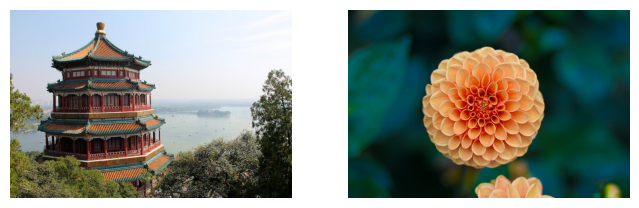

In [10]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))  # CHW → HWC formatına çevir
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

### Center Crop (Merkezi Kırpma)

`torchvision.transforms.v2` (kısaca `T`), görüntü ön işleme dönüşümlerini barındırır.  
`T.CenterCrop((70, 120))`: Görüntünün merkezi 70×120 piksel boyutunda kırpılır.  

**Neden kırpıyoruz?** Demo amaçlı daha küçük görüntülerle çalışmak için.


In [11]:
import torchvision
import torchvision.transforms.v2 as T

cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape  # (2, 3, 70, 120)

torch.Size([2, 3, 70, 120])

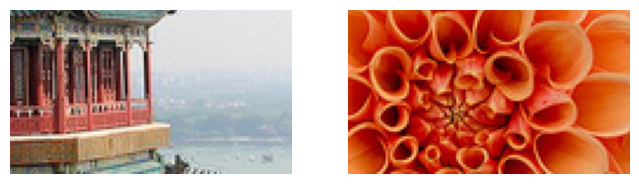

In [12]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])  # 1. kırpılmış görüntü
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])  # 2. kırpılmış görüntü

## 2.2 PyTorch ile Conv2d Katmanı Oluşturma

`nn.Conv2d(in_channels, out_channels, kernel_size)`:
- `in_channels=3`: RGB giriş (3 kanal)
- `out_channels=32`: 32 farklı feature map üretilecek (32 farklı kernel öğrenilecek)
- `kernel_size=7`: 7×7 boyutunda kernel

`torch.manual_seed(42)`: Rastgele ağırlıkların tekrarlanabilirliği için seed belirlenir.

**Çıktı boyutu formülü (padding olmadan):**  
`output_size = (input_size - kernel_size) / stride + 1`  
Yani: `(70-7)/1 + 1 = 64` ve `(120-7)/1 + 1 = 114`


In [13]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
fmaps = conv_layer(cropped_images)  # forward pass

In [14]:
fmaps.shape  # (2, 32, 64, 114) — batch=2, 32 feature map, 64×114 boyut

torch.Size([2, 32, 64, 114])

### Feature Map'leri Görselleştirme

İlk 2 batch ve ilk 2 feature map görüntüleniyor.  
`fmaps[image_idx, fmap_idx]`: Belirli bir görüntünün belirli bir feature map'i.  
`.detach()`: Gradient hesabından ayırır (sadece görselleştirme için gerekli).  
`cmap="gray"`: Gri tonlamalı görüntüleme.

**Rastgele başlatılmış kernel'ların neden kenar dedektörü gibi davrandığını göreceksiniz!**  
Bu tesadüf değil — kenar algılamak, görüntü işlemede çok işlevsel bir başlangıç noktasıdır.


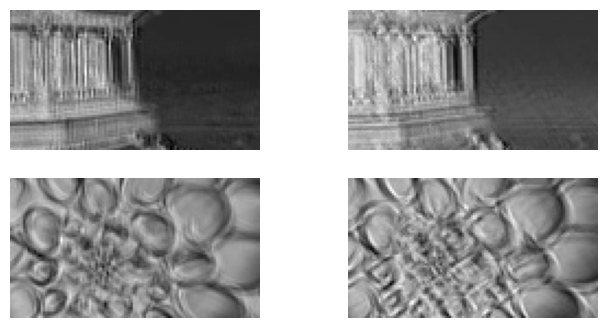

In [15]:
plt.figure(figsize=(8, 4))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap="gray")
        plt.axis("off")

plt.show()

**Gözlem:** Rastgele oluşturulan kernel'lar genellikle **edge detector** (kenar dedektörü) gibi davranır.  
Bu, görüntü işlemede çok faydalı bir başlangıç noktasıdır. Eğitim sırasında bu kernel'lar görev için daha özgün özellikleri tespit etmeyi öğrenir.


## 2.3 Padding (Kenar Doldurma)

**Sorun:** Padding olmadan her katmanda görüntü küçülür.  
**Çözüm:** `padding="same"` — çıktı feature map'in girişle aynı boyutta olmasını sağlamak için kenar sıfırlarla doldurulur (zero padding).

`padding="same"` ile: `output_size = ceil(input_size / stride)`  
Stride=1 ise: `output_size = input_size` (boyut korunur)


In [16]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7,
                       padding="same")  # boyutu koru
fmaps = conv_layer(cropped_images)

In [17]:
fmaps.shape  # (2, 32, 70, 120) — orijinal boyut korundu!

torch.Size([2, 32, 70, 120])

## 2.4 Stride (Adım Boyutu)

`stride=2` ile her iki pikselde bir adım atılır → feature map boyutu yarıya iner.  
`padding=3` ise 7×7 kernel için "same"-benzeri davranış sağlar.

**Stride'ın avantajı:** Hem boyutu küçültür hem de bir pooling katmanının gereksizliğini ortadan kaldırır.


In [18]:
# stride=2 kullandığımızda çıktı şeklini görelim
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2,
                       padding=3)
fmaps = conv_layer(cropped_images)
fmaps.shape  # (2, 32, 35, 60) — boyut yaklaşık yarıya indi

torch.Size([2, 32, 35, 60])

## 2.5 Conv2d Parametrelerinin Şekli

Bir Conv2d katmanının ağırlıkları (weights) ve bias'ı iki ayrı tensör olarak saklanır.

**Weight tensörü boyutu:** `[out_channels, in_channels, kernel_h, kernel_w]`  
= `[32, 3, 7, 7]` → 32 kernel, her biri 3 kanallı, 7×7 boyutlu

**Bias tensörü boyutu:** `[out_channels]` = `[32]` → Her feature map için bir bias terimi


In [19]:
conv_layer.weight.shape  # (32, 3, 7, 7) = 32 * 3 * 7 * 7 = 4704 ağırlık

torch.Size([32, 3, 7, 7])

In [20]:
conv_layer.bias.shape  # (32,) = 32 bias terimi

torch.Size([32])

## 2.6 Fonksiyonel API ile Conv2d

`torch.nn.functional.conv2d()`: Modül yerine doğrudan fonksiyon olarak convolution uygular.  
Önceden tanımlanmış filter tensörlerini ve bias'ları elle girerek çalıştırılabilir.  
Bu yaklaşım, özel araştırmalar için veya sabit (trainable olmayan) kernel'lar kullanmak istediğimizde faydalıdır.


In [21]:
import torch.nn.functional as F

torch.manual_seed(42)
filters = torch.randn([2, 3, 7, 7])  # 2 filter, 3 kanal, 7×7
biases = torch.zeros([2])             # 2 bias terimi (sıfır)
fmaps = F.conv2d(cropped_images, filters, biases, stride=1, padding="same")

In [22]:
fmaps.shape  # (2, 2, 70, 120)

torch.Size([2, 2, 70, 120])

## 2.7 Elle Oluşturulan Kernel'lar ile Kenar Tespiti

Burada iki özel kernel elle tasarlanır:  
- **Kernel 0:** Dikey sütunun ortası 1, geri kalan 0 → **dikey kenar dedektörü**  
- **Kernel 1:** Yatay satırın ortası 1, geri kalan 0 → **yatay kenar dedektörü**

`filters[0, :, :, 3] = 1` → 0. kernel'ın tüm kanallarında, tüm satırlarda, sütun indeksi 3 = 1  
`filters[1, :, 3, :] = 1` → 1. kernel'ın tüm kanallarında, satır indeksi 3'te, tüm sütunlar = 1

**Uygulamada manuel kernel oluşturmak gerekmez** — convolutional layer'lar bunları eğitim sırasında otomatik öğrenir.


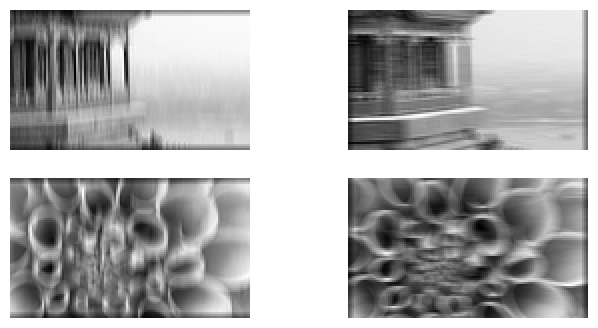

In [23]:
plt.figure(figsize=(8, 4))
filters = torch.zeros([2, 3, 7, 7])  # başlangıçta hepsi sıfır
filters[0, :, :, 3] = 1  # dikey çizgi (sütun 3'ü 1 yap)
filters[1, :, 3, :] = 1  # yatay çizgi (satır 3'ü 1 yap)
fmaps = F.conv2d(cropped_images, filters, biases, stride=1, padding="same")

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

**Zero Padding Artefaktı:**  
Sol sütundaki iki görüntünün üst ve altında, sağ sütundaki iki görüntünün sol ve sağında karanlık çizgiler göreceksiniz.  

Bu, zero padding'in yan etkisidir: görüntü kenarlarına sıfır eklendiğinde, dikey kenar kernel'ı görüntünün üst/alt kenarlarında tam olarak aktive olamaz, yatay kenar kernel'ı ise sol/sağ kenarlarında tam aktive olamaz.  
Önceki örnekte padding kullanılmadığından bu artefakt yoktu.


## 3. Pooling Layers (Havuzlama Katmanları)

### Amaç

Pooling layer'larının amacı girişi **alt örneklemek** (subsample / shrink), yani boyutu küçültmektir. Bu sayede:

- **Computational load** (hesaplama yükü) azalır
- **Memory usage** (bellek kullanımı) azalır
- **Parametre sayısı** azalır → overfitting riski düşer

Convolutional layer'lara benzer şekilde her nöron, önceki katmanın sınırlı sayıda nöronunun çıktısına bağlıdır (receptive field). Ancak pooling nöronunun **ağırlığı ya da bias'ı yoktur**; yalnızca max veya mean gibi bir fonksiyon uygular.

### Max Pooling

En yaygın pooling türü **max pooling**'dir. 2×2 kernel ile stride=2 kullanıldığında:
- Her 2×2 alandaki maksimum değer bir sonraki katmana geçer
- Diğer değerler **atılır** (bu yıkıcı bir işlemdir)
- Çıktının yüksekliği ve genişliği yarıya düşer

**Neden max pooling average pooling'den daha iyi?**
- Yalnızca en güçlü özellikleri korur, anlamsız olanları eler
- Sonraki katmanlara daha temiz bir sinyal sunar
- Daha güçlü **translation invariance** (öteleme değişmezliği) sağlar
- Biraz daha az hesaplama gerektirir

### Translation Invariance (Öteleme Değişmezliği)

Bir resim bir veya iki piksel sağa kaydırılsa bile, max pooling sonrası çıktı **aynı kalabilir**. Bu, objenin konumundan bağımsız sınıflandırma için idealdir.

Ancak bazı uygulamalarda bu istenilmez:
- **Semantic segmentation** gibi görevlerde her pikselin sınıfını bilmemiz gerekir
- Bu durumda **equivariance** (eşdeğişme) istenir: Giriş kaydığında çıktı da kaymalıdır

### Depthwise Max Pooling

Max pooling genellikle spatial (mekansal) boyutlarda uygulanır, ancak **depth (derinlik) boyutunda** da uygulanabilir. Bu, CNN'nin rotasyon, kalınlık, parlaklık gibi çeşitli özelliklere **invariant** olmasını öğrenmesini sağlar.

PyTorch'ta yerleşik bir depthwise pooling katmanı yoktur; özel bir modül yazmak gerekir.

### Global Average Pooling

Modern mimarilerde sıkça görülen bir diğer tür: **global average pooling**. Her feature map için tüm değerlerin ortalamasını alır ve **feature map başına tek bir sayı** üretir. Bu, spatial bilginin büyük bölümünü yok eder, ancak output layer'dan hemen önce çok kullanışlıdır.


## 3.1 Max Pooling ve Average Pooling

### Max Pooling

`nn.MaxPool2d(kernel_size=2)`: 2×2'lik pencerelerden en büyük değeri seçer, stride varsayılan olarak kernel_size'a eşit (2×2 pencerelerde örtüşme olmaz).  
Sonuç: Her iki boyut da yarıya iner.


In [24]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [25]:
output_max = max_pool(cropped_images)
# output_max.shape → (2, 3, 35, 60)  — boyutlar yarıya indi

### Average Pooling

`nn.AvgPool2d(kernel_size=2)`: 2×2 penceredeki 4 değerin ortalamasını alır.  
Max pooling'den daha yumuşak bir temsil üretir.


In [26]:
avg_pool = nn.AvgPool2d(kernel_size=2)

In [27]:
output_avg = avg_pool(cropped_images)

### Max Pooling vs Average Pooling Görselleştirme

`plt.subplot2grid((2, 3), (row, col), rowspan, colspan)`: Orijinal görüntü büyük sol panelde, iki pooling çıktısı küçük sağ panellerde gösterilir.


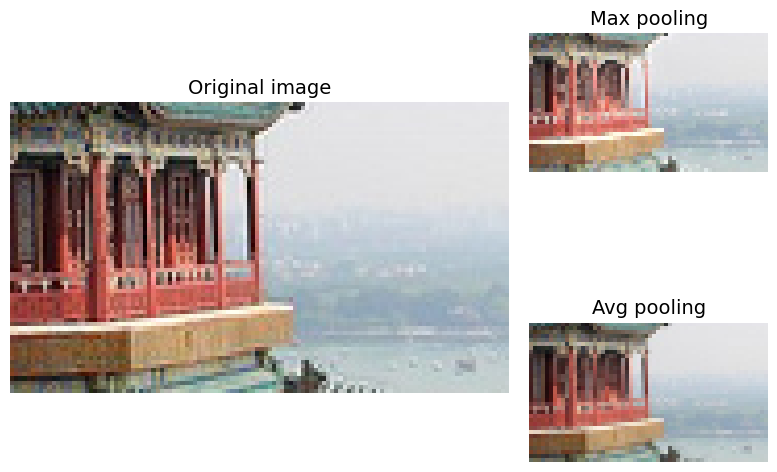

In [28]:
fig = plt.figure(figsize=(8, 6))

# Orijinal görüntü: 2 satır, 2 sütun kaplar (büyük panel)
ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(cropped_images[0].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title("Original image")

# Max Pooling çıktısı
ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.imshow(output_max[0].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title("Max pooling")

# Average Pooling çıktısı
ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[0].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()

## 3.2 Depth-wise Pooling (Derinlik Boyutunda Havuzlama)

Standart pooling yalnızca uzaysal boyutlarda (height, width) çalışır.  
**Depth-wise pooling** ise **channel (derinlik) boyutunda** pooling yapar — birden fazla feature map'i sıkıştırır.

### DepthMaxPool2 Sınıfı Açıklaması

1. `inputs.view(batch, channels, height * width)`: Uzaysal boyutları tek boyuta birleştir (H×W → HW)
2. `Z.permute(0, 2, 1)`: Spatial ve channel boyutlarını yer değiştir → (batch, HW, channels)
3. `F.max_pool1d(...)`: Kanal boyutunda max pooling yap
4. `Z.permute(0, 2, 1)`: Boyutları geri al
5. `.view(batch, -1, height, width)`: Orijinal uzaysal şekle dön


In [29]:
import torch.nn.functional as F

class DepthMaxPool2(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding

    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        Z = inputs.view(batch, channels, height * width)  # uzaysal boyutları birleştir
        Z = Z.permute(0, 2, 1)                            # (batch, HW, channels)
        Z = F.max_pool1d(Z, kernel_size=self.kernel_size, stride=self.stride,
                         padding=self.padding)             # kanal boyutunda max pool
        Z = Z.permute(0, 2, 1)                            # (batch, channels//k, HW)
        return Z.view(batch, -1, height, width)            # orijinal uzaysal şekle dön

## 3.3 Global Average Pooling (GAP)

**Global Average Pooling**, her feature map'i tek bir değere indirger (tüm piksel değerlerinin ortalaması).  
Modern CNN mimarilerinde fully connected katmanların yerine kullanılır → parametre sayısını dramatik şekilde azaltır.

### Üç Farklı Uygulama


#### 1. Yöntem: Sabit kernel boyutu (önerilmez)

Görüntü boyutunu tam olarak bilmeniz gerekir → esnek değil.


In [30]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))  # sabit boyuta bağımlı

In [31]:
output = global_avg_pool(cropped_images)
# output.shape → (2, 3, 1, 1)  — her feature map tek bir değere indi

#### 2. Yöntem: AdaptiveAvgPool2d (önerilen)

`nn.AdaptiveAvgPool2d(output_size=1)`: Çıktıyı 1×1 boyutuna uyarlar.  
Girdi boyutundan bağımsız çalışır → her boyuttaki görüntüyle kullanılabilir.


In [32]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)  # boyuttan bağımsız

In [33]:
output = global_avg_pool(cropped_images)
# output.shape → (2, 3, 1, 1)

#### 3. Yöntem: Tensor mean() ile doğrudan

`tensor.mean(dim=(2, 3), keepdim=True)`: Height (dim=2) ve width (dim=3) boyutları üzerinden ortalama alınır.  
`keepdim=True`: Boyut sayısı korunur (4D → 4D), sadece H ve W 1 olur.  
En basit ve esnek yöntem.


In [34]:
output = cropped_images.mean(dim=(2, 3), keepdim=True)
# output.shape → (2, 3, 1, 1)

## 4. CNN Architectures (CNN Mimarileri)

### Tipik CNN Yapısı

Standart bir CNN şöyle sıralanır:

```
[Conv + ReLU] × k → [MaxPool] → [Conv + ReLU] × k → [MaxPool] → ... → [Flatten] → [Dense] → [Output]
```

- Görüntü network içinde ilerledikçe **giderek küçülür** (height ve width azalır)
- Ama aynı zamanda **giderek derinleşir** (daha fazla feature map)
- En üstte birkaç **fully connected layer** ve son olarak softmax çıktısı

**İpucu:** 5×5 kernel'lı bir katman yerine **iki adet 3×3 kernel'lı katman** kullanmak genellikle daha iyidir:
- Daha az parametre kullanır
- Daha az hesaplama gerektirir
- Genellikle daha iyi performans gösterir

**İstisna:** İlk convolutional layer büyük bir kernel (5×5 veya 7×7) kullanabilir, stride=2 ile görüntüyü çok fazla bilgi kaybetmeden küçültür.

### ILSVRC ImageNet Challenge

CNN'lerin gelişimini ölçmenin iyi bir yolu bu yarışmadaki hata oranlarına bakmaktır:
- 2010: %26+ hata
- 2016: %2.3'ün altına düştü
- Sınıflandırma için **top-5 hata oranı** kullanılır (sistemin en güvenli 5 tahmininden hiçbiri doğru değilse hata sayılır)
- 1.000 sınıf, bazıları son derece benzer (120 köpek ırkı!)

---

### LeNet-5 (1998)

Belki en bilinen CNN mimarisi. Yann LeCun tarafından el yazısı rakam tanıma için geliştirildi.

| Katman | Tür | Map'ler | Boyut | Kernel | Stride | Aktivasyon |
|--------|-----|---------|-------|--------|--------|-----------|
| In | Giriş | 1 | 32×32 | — | — | — |
| C1 | Convolution | 6 | 28×28 | 5×5 | 1 | tanh |
| S2 | Avg pooling | 6 | 14×14 | 2×2 | 2 | tanh |
| C3 | Convolution | 16 | 10×10 | 5×5 | 1 | tanh |
| S4 | Avg pooling | 16 | 5×5 | 2×2 | 2 | tanh |
| C5 | Convolution | 120 | 1×1 | 5×5 | 1 | tanh |
| F6 | Fully connected | — | 84 | — | — | tanh |
| Out | Fully connected | — | 10 | — | — | RBF |

Modern implementasyonlarda: tanh yerine ReLU, average pooling yerine max pooling kullanılır.

---

### AlexNet (2012)

2012 ILSVRC yarışmasının galibi, %26'dan %17'ye düşen dramatik bir iyileşme sağladı. LeNet-5'e benzer ama çok daha büyük ve derin. Önemli özellikler:
- **ReLU activation function** kullanımı (tanh yerine) → çok daha hızlı training
- **Local Response Normalization (LRN)** katmanları (sonradan batch normalization'a yerini bıraktı)
- **Data augmentation** uygulandı
- **Dropout** ile regularization

---

### GoogLeNet (2014)

Google'dan çıkan bu mimari ILSVRC 2014'ü kazandı. AlexNet'e kıyasla 10 kat daha az parametre kullandı!

**Ana yenilik: Inception module**
Bir inception modülü, farklı kernel boyutlarına sahip convolutional layer'ları (1×1, 3×3, 5×5) ve bir max pooling layer'ı **paralel olarak** çalıştırır ve çıktılarını **concatenate** eder (derinlik boyutunda birleştirir).

**1×1 Convolutional Layer'ın Rolü:**
- Depth (derinlik) boyutunda örüntüleri tespit eder
- **Bottleneck layer** görevi görür: 3×3 ve 5×5 layer'lardan önce kanal sayısını azaltır → parametre ve hesaplama tasarrufu
- Inception modülünün daha az maliyetle zengin özellikler öğrenmesini sağlar

---

### ResNet (2015)

Kaiming He ve ekibi ILSVRC 2015'i %3.6 hata oranıyla kazandı. **152 katmanlı** bir CNN! 

**Temel sorun:** Çok derin ağlarda **vanishing gradient** problemi — alt katmanlara gradyanlar ulaşamaz ve öğrenemezler.

**Çözüm: Skip connections (Shortcut connections)**

Her residual unit'te giriş sinyali, unit'in çıktısına **doğrudan eklenir**:

$$\text{output} = F(\mathbf{x}) + \mathbf{x}$$

Ağ $F(\mathbf{x}) = h(\mathbf{x}) - \mathbf{x}$ **residual**'ı öğrenir; bu **residual learning** olarak adlandırılır.

**Neden etkili?**
- Training başında ağırlıklar sıfıra yakınken, residual unit yalnızca identity function (kimlik fonksiyonu) gibi davranır
- Eğer hedef fonksiyon identity'ye yakınsa (ki sıkça öyle olur), training çok hızlanır
- Birçok skip connection ile bazı katmanlar henüz öğrenmemiş olsa bile sinyal tüm ağa yayılabilir

**Feature map boyutu ve derinliği değiştiğinde:** Giriş ve çıktı şekli eşleşmez. Bu durumda skip connection'a stride=2 olan 1×1 convolutional layer eklenir.

---

### Xception (2016)

François Chollet (Keras'ın yazarı) tarafından önerilen bu mimari, GoogLeNet fikirlerini daha da ileri götürür. Inception modülleri yerine **depthwise separable convolution layer** kullanır.

**Temel fikir:** Spatial (mekansal) örüntüler ve cross-channel (kanallar arası) örüntüler **ayrı ayrı** modellenebilir:

- **Depthwise convolution:** Her giriş feature map'ine ayrı bir spatial filter uygular
- **Pointwise convolution:** 1×1 filter ile kanallar arası örüntüleri arar

**Avantajları:**
- Daha az parametre
- Daha az bellek kullanımı
- Daha az hesaplama
- Genellikle daha iyi performans

→ **İpucu:** Kanal sayısı az olan katmanlar (giriş katmanı gibi) hariç, separable convolution'ları varsayılan olarak kullanmayı düşünün.

---

### SENet — Squeeze-and-Excitation Network (2017)

ILSVRC 2017 şampiyonu, **%2.25 top-5 hata oranı**! Mevcut mimarilere (inception, ResNet) eklenen küçük bir **SE block** ile performansı artırır.

**SE Block nasıl çalışır?**
1. **Global average pooling**: Her feature map'in ortalamasını alır (256 feature map → 256 sayı)
2. **Squeeze**: Dense layer ile bu bilgiyi sıkıştırır (örn. 16 boyutlu vektör) — özellik kombinasyonlarının genel bir temsili
3. **Excitation**: Sigmoid çıktılı bir dense layer, her feature map için 0 ile 1 arasında bir **recalibration** skoru üretir
4. **Scaling**: Feature map'ler bu skorlarla çarpılır → gereksiz feature map'ler küçülür, önemli olanlar korunur

Örnek: Ağız ve burun feature map'leri güçlü aktive olduğunda SE block, göz feature map'ini de güçlendirmeyi öğrenir.

---

### Diğer Önemli Mimariler

**VGGNet (2014):** Çok basit ve klasik bir mimari (Oxford VGG grubu). 2 veya 3 conv + pooling katmanları tekrarı, küçük 3×3 filter'lar. Toplam 16-19 conv katmanı. Basitliğine rağmen çok güçlüdür.

**ResNeXt:** ResNet'i iyileştirir. Her residual unit, 3 conv katmanlı çok sayıda paralel yığın (örn. 32 yığın) içerir ve çıktılar toplanır. Daha geniş ağlar olmadan daha iyi accuracy sağlar.

**DenseNet:** Her katman, önceki *tüm* katmanların çıktılarına bağlıdır (sadece bir önceki katmana değil). Çok daha kısa, daha verimli, daha kolay eğitilebilir.

**MobileNet:** Depthwise separable convolution kullanan hafif mimari. Mobil cihazlar için tasarlanmıştır.

**EfficientNet:** Belki de bu listedeki en önemli model. **Compound scaling** yöntemi: Derinlik, genişlik ve çözünürlük birlikte *ilkeli bir şekilde* ölçeklendirilir.

**ConvNeXt:** ResNet'e benzer, ancak en iyi vision transformer mimarilerinden ilham alan tweaks içerir (örn. daha büyük kernel'lar 3×3 yerine 7×7).

---

### EfficientNet: Compound Scaling Detayları

Compute bütçesinin logaritmik ölçüsü $\phi$: Compute bütçesi ikiye katlandığında $\phi$ 1 artar.

- Derinlik: $\alpha^\phi$ ile ölçeklenir
- Genişlik: $\beta^\phi$ ile ölçeklenir  
- Çözünürlük: $\gamma^\phi$ ile ölçeklenir

$\alpha, \beta, \gamma > 1$ ve $\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$ olmalıdır.

EfficientNetB0 için grid search ile bulunan değerler: $\alpha=1.2, \beta=1.1, \gamma=1.1$

Bu formülle EfficientNetB1'den B7'ye kadar büyüyen mimariler oluşturuldu.


---

## 4.1 Fashion MNIST için Temel CNN

Fashion MNIST, 10 farklı giysi kategorisinden oluşan 28×28 piksel gri tonlamalı görüntüler içeren bir veri setidir.

### Model Mimarisi

| Katman | Tür | Parametreler |
|---|---|---|
| Conv2d | Evrişimli | 1→64 kanal, 7×7 kernel |
| MaxPool2d | Havuzlama | 2×2 |
| Conv2d | Evrişimli | 64→128 kanal, 3×3 kernel |
| Conv2d | Evrişimli | 128→128 kanal, 3×3 kernel |
| MaxPool2d | Havuzlama | 2×2 |
| Conv2d | Evrişimli | 128→256 kanal, 3×3 kernel |
| Conv2d | Evrişimli | 256→256 kanal, 3×3 kernel |
| MaxPool2d | Havuzlama | 2×2 |
| Flatten | Düzleştirme | — |
| Linear | Tam bağlı | 2304→128 |
| Dropout | Düzenlileştirme | 0.5 |
| Linear | Tam bağlı | 128→64 |
| Dropout | Düzenlileştirme | 0.5 |
| Linear | Çıktı | 64→10 |

`functools.partial()` ile `DefaultConv2d` kısayolu tanımlanır: her seferinde `kernel_size=3, padding="same"` yazmaktan kaçınılır.


In [40]:
# Donanımı kontrol et (GPU varsa 'cuda', yoksa 'cpu')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")

model = nn.Sequential(
    # ... model katmanların ...
    nn.Linear(in_features=64, out_features=10),
).to(device) # Artık 'device' tanımlı olduğu için hata vermeyecektir

In [41]:
from functools import partial

torch.manual_seed(42)  # tekrarlanabilirlik için
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")  # kısayol

model = nn.Sequential(
    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

## 4.2 Eğitim ve Değerlendirme Fonksiyonları

### `evaluate_tm()` — Model Değerlendirme

1. `model.eval()`: Modeli eval moduna alır (Dropout ve BatchNorm eğitim modundan çıkar)
2. `metric.reset()`: Önceki metrik değerlerini sıfırlar
3. `torch.no_grad()`: Gradient hesabını devre dışı bırakır (bellek ve hız tasarrufu)
4. Her batch için tahmin yapılır ve metrik güncellenir
5. `metric.compute()`: Birikmiş metrik değerini döndürür

### `train()` — Eğitim Döngüsü

Her epoch için:
1. **Forward pass:** Model tahmin üretir (`y_pred = model(X_batch)`)
2. **Loss hesaplama:** `loss = loss_fn(y_pred, y_batch)`
3. **Backward pass:** `loss.backward()` gradyanları hesaplar
4. **Parametre güncelleme:** `optimizer.step()` ağırlıkları günceller
5. **Gradyan sıfırlama:** `optimizer.zero_grad()` bir sonraki adım için gradyanları sıfırlar
6. Train ve validation metrikleri loglanır


In [42]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()          # eval modu: dropout kapalı, batchnorm sabit
    metric.reset()        # önceki hesaplamaları sıfırla
    with torch.no_grad():  # gradient hesabı yapma → hız kazanımı
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # metriği güncelle
    return metric.compute()  # toplam metrik değerini döndür

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()  # train modu: dropout aktif, batchnorm güncel
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)               # 1) forward pass
            loss = loss_fn(y_pred, y_batch)       # 2) loss hesapla
            total_loss += loss.item()
            loss.backward()                       # 3) backward pass (gradyanlar)
            optimizer.step()                      # 4) parametreleri güncelle
            optimizer.zero_grad()                 # 5) gradyanları sıfırla
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

## 4.3 Fashion MNIST Veri Seti Yükleme

`torchvision.datasets.FashionMNIST`: Veri setini indirir (yoksa) ve yükler.  
`T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])`:
- `T.ToImage()`: PIL image veya numpy array'i PyTorch tensor'una çevirir
- `T.ToDtype(torch.float32, scale=True)`: uint8 piksel değerlerini float32'ye ölçekler (0-1 arasına normalize eder)

`torch.utils.data.random_split([55_000, 5_000])`: 60.000 eğitim örneğini 55.000 train + 5.000 validation olarak böler.


In [43]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

## 4.4 DataLoader Oluşturma

`DataLoader`, veri setini mini-batch'lere böler ve eğitim döngüsüne akışını sağlar:
- `batch_size=32`: Her iterasyonda 32 örnek
- `shuffle=True` (sadece train): Her epoch'ta örneklerin sırası karıştırılır → overfitting azalır


In [44]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

## 4.5 Model Eğitimi

**Optimizer — AdamW:**  
Adam (Adaptive Moment Estimation) + Weight Decay düzeltmesi. Adaptif öğrenme hızları kullanır → genellikle SGD'den daha hızlı yakınsar.

**Loss Function — CrossEntropyLoss:**  
Çok sınıflı sınıflandırma için standart kayıp fonksiyonu. Softmax + Negative Log Likelihood kombinasyonudur.

**Metric — Accuracy:**  
`torchmetrics.Accuracy(task="multiclass", num_classes=10)`: 10 sınıflı doğruluk metriği.


In [45]:
n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.8401, train metric: 0.6794, valid metric: 0.8126
Epoch 2/20, train loss: 0.5124, train metric: 0.8111, valid metric: 0.8708
Epoch 3/20, train loss: 0.4234, train metric: 0.8509, valid metric: 0.8836
Epoch 4/20, train loss: 0.3718, train metric: 0.8721, valid metric: 0.8850
Epoch 5/20, train loss: 0.3357, train metric: 0.8849, valid metric: 0.8962
Epoch 6/20, train loss: 0.3060, train metric: 0.8955, valid metric: 0.9008
Epoch 7/20, train loss: 0.2890, train metric: 0.9007, valid metric: 0.9070
Epoch 8/20, train loss: 0.2672, train metric: 0.9096, valid metric: 0.9018
Epoch 9/20, train loss: 0.2580, train metric: 0.9130, valid metric: 0.9100
Epoch 10/20, train loss: 0.2445, train metric: 0.9177, valid metric: 0.9044
Epoch 11/20, train loss: 0.2335, train metric: 0.9204, valid metric: 0.9080
Epoch 12/20, train loss: 0.2226, train metric: 0.9246, valid metric: 0.8986
Epoch 13/20, train loss: 0.2145, train metric: 0.9258, valid metric: 0.9066
Epoch 14/20, train lo

---
## 4.6 LeNet-5 Mimarisi

**LeNet-5** (1998, Yann LeCun), el yazısı rakam tanıma için geliştirilen tarihi ilk CNN'dir.

### Katman Yapısı

| Katman | Tür | Feature Map | Boyut | Kernel | Stride | Aktivasyon |
|---|---|---|---|---|---|---|
| In | Giriş | 1 | 32×32 | — | — | — |
| C1 | Convolution | 6 | 28×28 | 5×5 | 1 | tanh |
| S2 | Avg Pooling | 6 | 14×14 | 2×2 | 2 | tanh |
| C3 | Convolution | 16 | 10×10 | 5×5 | 1 | tanh |
| S4 | Avg Pooling | 16 | 5×5 | 2×2 | 2 | tanh |
| C5 | Convolution | 120 | 1×1 | 5×5 | 1 | tanh |
| F6 | Fully Connected | — | 84 | — | — | tanh |
| Out | Fully Connected | — | 10 | — | — | RBF |

### Önemli Notlar

- **Giriş:** MNIST görüntüleri (28×28) sıfır-padding ile 32×32'ye büyütülür ve normalize edilir.
- **Ortalama Pooling:** Her nöron girdilerin ortalamasını alır, öğrenilebilir bir katsayı ile çarpar ve bias ekler.
- **C3'te Kısmi Bağlantı:** C3'teki nöronlar S2'nin yalnızca 3 veya 4 feature map'ine bağlıdır (6'sının hepsine değil).
- **Çıktı Katmanı:** Öklid uzaklığı tabanlı RBF nöronlar kullanır — modern cross-entropy'den farklı.

Bugün artık LeNet-5 mimarisinin tüm detayları kullanılmıyor, ancak tarihsel önemi büyük.


---
## 4.7 Xception ve Separable Convolution

### Depthwise Separable Convolution (Derinlik Ayrıştırılmış Evrişim)

Standart convolution iki şeyi aynı anda yapar:
1. **Uzaysal filtreleme** (her kanal için ayrı kernel)
2. **Kanal kombinasyonu** (kanalları birleştirme)

**Depthwise Separable Convolution** bunları iki ayrı adıma böler:

1. **Depthwise convolution:** Her kanal için ayrı ayrı uzaysal filtreleme (`groups=in_channels`)  
   → Her kanal kendi 2D kernel'ı ile konvolüsyona girer
2. **Pointwise convolution:** 1×1 convolution ile kanalları karıştırma  
   → Kanal boyutunu değiştirmek için kullanılır

**Avantaj:** Parametre sayısı ve hesaplama maliyeti çok daha az, benzer doğruluk.

`groups=in_channels`: Her kanalın kendi kernel'ı olduğunu belirtir (depthwise).


In [46]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        # 1. Depthwise conv: her kanal kendi kernel'ı ile konvolüsyona girer
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride=stride,
            padding=padding, groups=in_channels)  # groups=in_channels → depthwise
        # 2. Pointwise conv: 1×1 kernel ile kanalları karıştır
        self.pointwise_conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))

---
# 🔗 5. ResNet-34 Mimarisinin Uygulanması

## ResNet (Residual Network) Nedir?

**Problem:** Çok derin ağlarda gradient'lar katman katman geriye yayılırken giderek küçülür (vanishing gradient problemi) ve eğitim imkansız hale gelir.

**Çözüm (2015, He ve ark.):** **Skip connection** (artık bağlantı) — katmanın çıktısına girdiyi doğrudan ekleme.

### Residual Unit Formülü

```
output = F(inputs) + skip_connection(inputs)
```

- `F(inputs)`: İki Conv-BN-ReLU katmanından geçen "öğrenilecek artık kısım"
- `skip_connection(inputs)`: Doğrudan bağlantı (boyut farklıysa 1×1 conv ile ayarlanır)

## 5.1 ResidualUnit Sınıfı

**Main path (ana yol):** Conv → BatchNorm → ReLU → Conv → BatchNorm  
**Skip connection (atlama yolu):**
- `stride=1` ve aynı kanal sayısı → `nn.Identity()` (hiçbir şey yapmaz, girdiyi doğrudan ilet)
- `stride>1` veya farklı kanal sayısı → 1×1 Conv + BatchNorm (boyutu eşleştirmek için)

**Son aktivasyon:** `F.relu(main + skip)` — TOPLAMA SONRASI ReLU


In [47]:
class ResidualUnit(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        DefaultConv2d = partial(
            nn.Conv2d, kernel_size=3, stride=1, padding=1, bias=False)
        # Ana yol: Conv → BN → ReLU → Conv → BN
        self.main_layers = nn.Sequential(
            DefaultConv2d(in_channels, out_channels, stride=stride),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            DefaultConv2d(out_channels, out_channels),
            nn.BatchNorm2d(out_channels),
        )
        # Skip connection: boyut eşleşmiyorsa 1×1 conv ile uyarla
        if stride > 1:
            self.skip_connection = nn.Sequential(
                DefaultConv2d(in_channels, out_channels, kernel_size=1,
                              stride=stride, padding=0),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip_connection = nn.Identity()  # doğrudan ilet

    def forward(self, inputs):
        return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

## 5.2 ResNet-34 Sınıfı

ResNet-34 mimarisi şu blok gruplarından oluşur:
- 3 × ResidualUnit (64 filter)
- 4 × ResidualUnit (128 filter)
- 6 × ResidualUnit (256 filter)
- 3 × ResidualUnit (512 filter)

Toplam: 34 ağırlıklı katman (bağımsız residual birimler sayılarak)

**Önemli Detaylar:**
- `bias=False`: BatchNorm zaten bir bias terimi öğrendiğinden Conv'da bias gereksizdir
- `stride=2`: Her yeni filter sayısına geçişte boyutu yarıya indir
- `nn.LazyLinear(10)`: Flatten'dan gelen boyutu otomatik algılar

`nn.AdaptiveAvgPool2d(output_size=1)`: Global Average Pooling → feature map'leri tek değere indir  
`nn.Flatten()`: (batch, 512, 1, 1) → (batch, 512)


In [48]:
class ResNet34(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2,
                      padding=3, bias=False),  # 224 → 112
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),  # 112 → 56
        ]
        prev_filters = 64
        for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
            stride = 1 if filters == prev_filters else 2  # boyutu küçült
            layers.append(ResidualUnit(prev_filters, filters, stride=stride))
            prev_filters = filters
        layers += [
            nn.AdaptiveAvgPool2d(output_size=1),  # global average pooling
            nn.Flatten(),
            nn.LazyLinear(10),  # çıktı boyutunu otomatik algıla
        ]
        self.resnet = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.resnet(inputs)

### ResNet-34 ile Test

224×224'lük rastgele tensörlerle modelin çalıştığını doğrulayalım.  
Bu gerçek ImageNet görüntü boyutudur.


In [49]:
torch.manual_seed(42)
model = ResNet34().to(device)
images = torch.randn(2, 3, 224, 224).to(device)  # 2 adet rastgele görüntü
model(images)  # shape: (2, 10)

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


tensor([[-0.4890,  0.4186, -0.0087, -1.1758,  0.3053, -0.1736, -0.1364, -0.0984,
         -0.1305, -1.1044],
        [-0.4840,  0.4538,  0.0303, -1.2327, -0.0140, -0.3619, -0.2057,  0.0192,
         -0.0404, -1.0207]], grad_fn=<AddmmBackward0>)

## 6. Depthwise Separable Convolution (Xception İçin)

PyTorch'ta `SeparableConv2d` yerleşik olarak bulunmadığından kendi implementasyonumuzu yazıyoruz.

**İki aşama:**
1. **Depthwise convolution**: `groups=in_channels` ile her giriş kanalı için ayrı spatial filter
2. **Pointwise convolution**: `kernel_size=1` ile kanallar arası kombinasyonları öğren

`groups` argümanı: Giriş kanallarını bağımsız gruplara böler. `groups=in_channels` durumunda her kanal kendi filter'ını alır → **depthwise convolution**.


In [50]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        # Depthwise conv: Her kanalın kendi spatial filter'ı var
        # groups=in_channels → Her input kanalı ayrı bir grup → Kanallar arası bağlantı yok
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size,
            stride=stride, padding=padding,
            groups=in_channels  # ← Anahtar parametre!
        )
        # Pointwise conv: 1×1 kernel ile kanallar arası örüntüleri yakala
        self.pointwise_conv = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, stride=1, padding=0
        )

    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))

# Test edelim
sep_conv = SeparableConv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
test_input = torch.randn(2, 32, 28, 28)
output = sep_conv(test_input)
print(f"Giriş: {test_input.shape} → Çıktı: {output.shape}")

# Parametre karşılaştırması
regular_conv = nn.Conv2d(32, 64, kernel_size=3, padding=1)
print(f"\nRegular Conv2d parametre sayısı: {sum(p.numel() for p in regular_conv.parameters()):,}")
print(f"Separable Conv2d parametre sayısı: {sum(p.numel() for p in sep_conv.parameters()):,}")
print("→ Separable convolution daha az parametre kullanıyor!")


Giriş: torch.Size([2, 32, 28, 28]) → Çıktı: torch.Size([2, 64, 28, 28])

Regular Conv2d parametre sayısı: 18,496
Separable Conv2d parametre sayısı: 2,432
→ Separable convolution daha az parametre kullanıyor!


## 7. GPU RAM Gereksinimleri: Inference vs Training

### RAM Hesabı Örneği

200 adet 5×5 filter, stride=1, "same" padding, 150×100 RGB görüntü için:

- **Parametre sayısı:** (5×5×3+1) × 200 = **15,200** (çok az!)
- **Output feature maps:** 200 × 150 × 100 × 32 bit = **~12 MB** RAM (tek bir instance için)
- **100 instance'lık batch:** 12 MB × 100 = **1.2 GB RAM** → yalnızca tek bir katman!

Karşılaştırma: Fully connected layer bu iş için ≈135 **milyar** parametre isterdi.

### Inference vs Training RAM Farkı

**Inference (tahmin) sırasında:**
- Bir katmanın RAM'i, bir sonraki katman hesaplandığında serbest bırakılabilir
- Yalnızca iki ardışık katman kadar RAM gerekir

**Training sırasında:**
- Forward pass'te hesaplanan her şey, backward pass (gradient hesabı) için **saklanmak zorundadır**
- Tüm katmanların RAM'i aynı anda tutulur → çok daha fazla RAM

### Out-of-Memory Sorununu Çözmek İçin

- **Batch size'ı küçült** (en basit çözüm)
- **Gradient accumulation**: Her batch sonrası ağırlık güncelleme yerine, birkaç batch sonrası güncelle
- **Stride ile boyut küçült**, bazı katmanları kaldır
- **16-bit float** (FP16) kullan
- CNN'i birden fazla cihaza dağıt
- En çok bellek kullanan modülleri CPU'ya taşı: `module.to("cpu")`
- **Activation checkpointing** (gradient checkpointing)

### Activation Checkpointing (Gradient Checkpointing)

Forward pass sırasında tüm aktivasyonları saklamak yerine, yalnızca bazı **checkpoint** noktalarını sakla. Backward pass sırasında eksik aktivasyonlar **kısmi bir forward pass** ile yeniden hesaplanır.

`checkpoint(foo, x)` kullanımı:
- Inference'ta hiçbir fark olmaz
- Training'de `foo`'nun aktivasyonları forward pass'te saklanmaz; backward pass'te gerektiğinde yeniden hesaplanır

**Uyarı:** Forward pass aynı giriş için aynı sonucu üretmelidir (in-place işlemler yasak, random state kontrol edilmeli).

### Reversible Residual Networks (RevNets)

2017'de Aidan Gomez ve ekibi tarafından önerilen devrimci bir çözüm: **Forward pass sırasında hiçbir aktivasyonu saklamadan** backpropagation yapmak!

Her **reversible layer** iki giriş ve iki çıktı alır:
$$y_1 = x_1 + f(x_2)$$
$$y_2 = g(y_1) + x_2$$

Backward pass için girişler **çıktılardan yeniden hesaplanabilir:**
$$x_2 = y_2 - g(y_1)$$
$$x_1 = y_1 - f(x_2)$$

**Kısıtlamalar:**
- `f` ve `g` fonksiyonları çıktı şeklini giriş şekliyle aynı tutmalıdır
- Stride > 1 veya "valid" padding kullanan katmanlar RevNet trickine uygun değildir
- Bu tür katmanların aktivasyonları (genellikle az sayıda) yine de saklanmalıdır

RevNet'ler yalnızca CNN'lerle sınırlı değildir — **Reformer** (Transformer mimarisi) de RevNet'leri temel alır.


In [51]:
# Activation Checkpointing Demo
from torch.utils.checkpoint import checkpoint

# Büyük bir modül için checkpointing kullanımı:
# Normalde:  z = some_big_module(x)
# Checkpoint: z = checkpoint(some_big_module, x)

# Demo:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
    
    def forward(self, x, use_checkpoint=False):
        if use_checkpoint:
            # Training sırasında aktivasyonları saklamaz; backward pass'te yeniden hesaplar
            return checkpoint(self.block, x, use_reentrant=False)
        else:
            return self.block(x)

model_demo = SimpleCNN()
x = torch.randn(2, 3, 64, 64, requires_grad=True)

# Normal forward
out_normal = model_demo(x, use_checkpoint=False)
print(f"Normal çıktı şekli: {out_normal.shape}")

# Checkpointed forward  
out_ckpt = model_demo(x, use_checkpoint=True)
print(f"Checkpointed çıktı şekli: {out_ckpt.shape}")
print("İki çıktı eşit mi:", torch.allclose(out_normal, out_ckpt, atol=1e-6))


Normal çıktı şekli: torch.Size([2, 64, 64, 64])
Checkpointed çıktı şekli: torch.Size([2, 64, 64, 64])
İki çıktı eşit mi: True


## 8. TorchVision Pretrained Models Kullanımı

### Neden Scratch'ten Yazmayalım?

GoogLeNet, ResNet, ConvNeXt gibi standart modelleri sıfırdan uygulamanıza gerek yoktur. TorchVision birkaç satır kodla hazır **pretrained** (önceden eğitilmiş) modeller sunar.

**Diğer kaynaklar:**
- **TIMM** (PyTorch Image Models): Pretrained sınıflandırma modelleri + data loader'lar + augmentation araçları
- **Hugging Face Hub**: Her türlü pretrained model

### Pretrained Model Yükleme

Weights (ağırlıklar) `Torch Hub`'dan otomatik indirilir ve `~/.cache/torch/hub` altında önbelleklenir.

**ImageNet-1K:** 1000 sınıf içerir.


---

## Neden Pretrained Model?

Büyük veri setleri (ImageNet: 1.2 milyon görüntü, 1000 sınıf) üzerinde eğitmek hem zaman hem kaynak açısından çok maliyetlidir.  
**Transfer learning** — önceden eğitilmiş modeli alıp yeni bir görev için uyarlamak — çok daha etkili bir yaklaşımdır.

## 8.1 ConvNeXt Modelini Yükleme

**ConvNeXt (2022):** Vision Transformer'lardan ilham alan, modern tekniklerle iyileştirilmiş CNN mimarisi.  
`IMAGENET1K_V1`: ImageNet-1K veri setinde eğitilmiş önceki sürüm ağırlıkları.  
`.to(device)`: Modeli GPU/CPU'ya taşır.


In [52]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

### Model İndirme Dizini

`torch.hub.get_dir()`: İndirilen modellerin nereye kaydedildiğini gösterir.


In [53]:
torch.hub.get_dir()  # örn: '~/.cache/torch/hub'

'/Users/livanurkaranfil/.cache/torch/hub'

### Mevcut Modelleri Listeleme

`torchvision.models.list_models()`: Tüm mevcut önceden eğitilmiş model isimlerini döndürür.


In [54]:
torchvision.models.list_models()  # resnet18, vgg16, efficientnet_b0, ... vb.

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

### Belirli Bir Model için Ağırlık Seçenekleri

`torchvision.models.get_model_weights("convnext_base")`: convnext_base modeli için mevcut önceden eğitilmiş ağırlık setlerini listeler.


In [55]:
list(torchvision.models.get_model_weights("convnext_base"))

[ConvNeXt_Base_Weights.IMAGENET1K_V1]

## 8.2 Görüntüleri Ön İşleme ve Tahmin

### Görüntü Ön İşleme (Transform)

Her pretrained modelin kendi beklediği normalizasyon ve boyut gereksinimleri vardır.  
`weights.transforms()`: Bu modelin beklediği ön işleme pipeline'ını otomatik oluşturur.  
→ Yeniden boyutlandırma, kırpma, normalizasyon (ImageNet ortalama/std) içerir.


In [56]:
transform = weights.transforms()
preprocessed_images = transform(sample_images_permuted)

### Inference (Çıkarım)

`model.eval()`: Modeli değerlendirme moduna al (BatchNorm ve Dropout eğitim modundan çıkar).  
`torch.no_grad()`: Gradient hesabı yapma → bellek tasarrufu ve hız artışı.  
`y_logits`: Softmax uygulanmamış ham skor tensörü, shape: (2, 1000)


In [57]:
model.eval()
with torch.no_grad():
    y_logits = model(preprocessed_images.to(device))

In [58]:
y_logits  # raw logit değerleri, her görüntü için 1000 sınıf puanı

tensor([[ 0.9411, -0.3203, -0.3067,  ...,  0.2110,  0.4626, -0.2570],
        [-0.6901, -0.6672, -0.8606,  ...,  0.9287,  4.1098, -0.8371]])

In [59]:
y_logits.shape  # (2, 1000) — 2 görüntü, 1000 ImageNet sınıfı

torch.Size([2, 1000])

### Sınıf Tahminleri

`torch.argmax(y_logits, dim=1)`: Her görüntü için en yüksek logit değerine sahip sınıfın index'ini döndürür.


In [60]:
y_pred = torch.argmax(y_logits, dim=1)
y_pred  # örn: tensor([985, 354])

tensor([698, 985])

### Sınıf İsimleri

`weights.meta`: Model metadata sözlüğü.  
`weights.meta["categories"]`: ImageNet sınıf isimlerinin listesi (1000 adet).


In [61]:
weights.meta.keys()

dict_keys(['min_size', 'categories', 'recipe', '_docs', 'num_params', '_metrics', '_ops', '_file_size'])

In [62]:
class_names = weights.meta["categories"]
[class_names[class_id] for class_id in y_pred]  # tahmin edilen sınıf isimleri

['palace', 'daisy']

### Top-3 Tahminler

`y_logits.topk(k=3, dim=1)`: Her görüntü için en yüksek 3 logit değerini ve index'lerini döndürür.  
Tek bir en iyi tahmin yerine birden fazla olası sınıf görmek daha bilgi vericidir.


In [63]:
y_top3_logits, y_top3_class_ids = y_logits.topk(k=3, dim=1)
[[class_names[class_id] for class_id in top3] for top3 in y_top3_class_ids]

[['palace', 'monastery', 'lakeside'], ['daisy', 'pot', 'ant']]

### Softmax ile Olasılık Hesaplama

`softmax(dim=1)`: Logit değerlerini 0-1 arasında olasılıklara dönüştürür.  
Tüm olasılıkların toplamı = 1.0 (normalize edilmiş dağılım).


In [64]:
y_top3_logits.softmax(dim=1)  # top-3 sınıflar için olasılık değerleri

tensor([[0.8618, 0.1185, 0.0197],
        [0.8106, 0.0964, 0.0930]])

### TorchVision Model Karşılaştırması

| Model | Top-1 Acc | Top-5 Acc | Parametre | GFLOPs |
|-------|-----------|-----------|-----------|--------|
| MobileNet v3 small | 67.7% | 87.4% | 2.5M | 0.1 |
| EfficientNet B0 | 77.7% | 93.5% | 5.3M | 0.4 |
| GoogLeNet | 69.8% | 89.5% | 6.6M | 1.5 |
| EfficientNet v2 small | 84.2% | 96.9% | 21.5M | 8.4 |
| ResNet 34 | 73.3% | 91.4% | 21.8M | 3.7 |
| ConvNeXt Tiny | 82.6% | 96.1% | 28.6M | 4.5 |
| ResNet 152 | 82.3% | 96.0% | 60.2M | 11.5 |
| EfficientNet B7 | 84.1% | 96.9% | 66.3M | 37.8 |
| EfficientNet v2 large | 85.8% | 97.8% | 118.5M | 56.1 |
| ConvNeXt Large | 84.4% | 97.0% | 197.8M | 34.4 |

**Seçim Kriterleri:**
- **Accuracy mı?** → EfficientNet v2 large veya ConvNeXt Large
- **Model boyutu / mobil cihaz mı?** → MobileNet v3 small veya EfficientNet B0
- **Hız mı?** → MobileNet veya EfficientNet küçük varyantlar
- **Enerji tüketimi mi?** → Küçük ve verimli modeller tercih edilmeli

**Büyük modeller için RAM dikkat!**

ConvNeXt Large (200M parametre): 800 MB parametre, ancak inference'ta görüntü başına ~5 GB GPU RAM gerekebilir. Training'de ise çok daha fazla.


## 9. Transfer Learning & Fine-Tuning

### Ne Zaman Kullanılır?

Kendi görüntü sınıflandırıcınızı oluşturmak istiyorsunuz ama yeterli veriniz yok. **Transfer learning** (aktarım öğrenmesi) ile pretrained bir modelin alt katmanlarını yeniden kullanabilirsiniz.

## Transfer Learning Süreci

1. **Pretrained modeli yükle** (ConvNeXt, ImageNet ağırlıkları)
2. **Sınıflandırıcı başlığı değiştir** (1000 sınıf → 102 çiçek sınıfı)
3. **Önceki katmanları dondur** (sadece yeni başlık eğitilir)
4. **Birkaç epoch eğit** (başlığı hızlıca uyarla)
5. **Tüm katmanları çöz ve fine-tune yap** (daha derin eğitim)

## 9.1 Veri Seti Yükleme (Flowers102)

`functools.partial` ile `DefaultFlowers102` kısayolu oluşturulur.  
Flowers102: 102 farklı çiçek türü, her sınıf için 40-258 görüntü.




In [65]:
DefaultFlowers102 = partial(torchvision.datasets.Flowers102, root="datasets",
                            transform=weights.transforms(), download=True)
train_set = DefaultFlowers102(split="train")
valid_set = DefaultFlowers102(split="val")
test_set = DefaultFlowers102(split="test")

100%|██████████| 344862509/344862509 [00:47<00:00, 7250656.16it/s]


Extracting datasets/flowers-102/102flowers.tgz to datasets/flowers-102


100%|██████████| 502/502 [00:00<00:00, 626835.55it/s]


100%|██████████| 14989/14989 [00:00<00:00, 10330007.01it/s]


In [66]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

### Sınıf İsimleri

102 çiçek türünün İngilizce isimleri.


In [67]:
class_names = ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 
               'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 
               'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 
               'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 
               'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 
               'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 
               'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 
               'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 
               'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 
               'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 
               'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 
               'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 
               'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 
               'orange dahlia', 'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 
               'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 
               'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 
               'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory', 
               'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 
               'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 
               'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum', 
               'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 
               'mallow', 'mexican petunia', 'bromelia', 'blanket flower', 
               'trumpet creeper', 'blackberry lily']

### İlk 12 Sınıfın Görselleştirilmesi

Her sınıfın ilk görüntüsü 3×4 grid'e yerleştirilir.  
`{y: img for img, y in flowers_to_display}` dict comprehension: Her sınıf için son görüntüyü saklar.  
`sorted(...)[:12]`: İlk 12 sınıfı sıralı olarak seç.


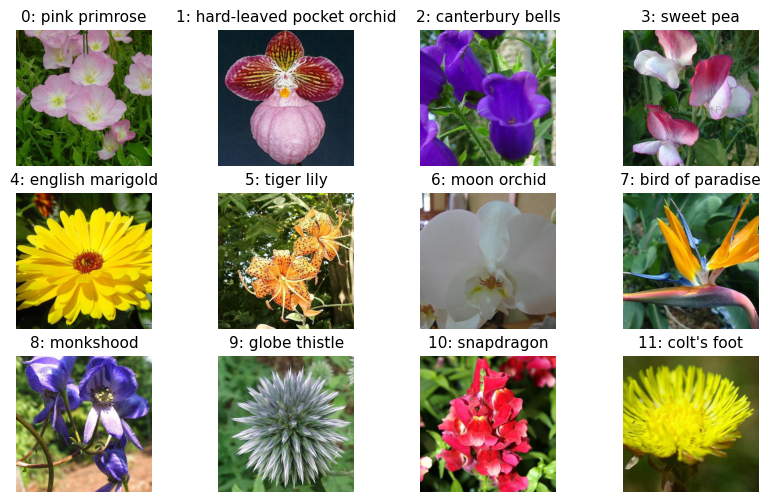

In [68]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])
flowers_to_display = DefaultFlowers102(split="train", transform=transform)
sample_flowers = sorted({y: img for img, y in flowers_to_display}.items())[:12]

plt.figure(figsize=(10, 6))
for class_id, image in sample_flowers:
    if class_id == 12: break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

## 9.2 Model Mimarisini İnceleme

`model.named_children()`: Modelin birinci seviye alt modüllerini (isim, modül) çiftleri olarak döndürür.


In [69]:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [70]:
model.classifier  # ConvNeXt'in sınıflandırıcı başlığı

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

## 9.3 Sınıflandırıcı Başlığını Değiştirme

`model.classifier[2]`: ConvNeXt'in son Linear katmanı (1000 çıkış → 102 çıkışa değiştir).  
`nn.Linear(1024, n_classes)`: 1024 özellikten 102 çiçek sınıfına projeksiyon.  
`.to(device)`: Yeni katmanı da GPU'ya taşı.


In [71]:
n_classes = 102  # len(class_names) == 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

## 9.4 Önceden Eğitilmiş Katmanları Dondurma

**Neden dondurulur?** Pretrained ağırlıklar milyonlarca görüntüden öğrenilmiş değerli temsiller içerir.  
Sadece yeni başlığı eğitmek daha hızlı ve veri açısından daha verimlidir.

`param.requires_grad = False`: Bu parametre için gradient hesaplanmaz → güncellenmez.  
Önce tümünü dondur, sonra sadece classifier'ı çöz.


In [72]:
for param in model.parameters():
    param.requires_grad = False  # tüm parametreleri dondur

for param in model.classifier.parameters():
    param.requires_grad = True   # sadece classifier'ı eğitilebilir yap

## 9.5 İlk Eğitim (Sadece Başlık)

İlk aşamada sadece yeni sınıflandırıcı başlığı eğitilir.  
5 epoch sonra validation accuracy'yi gözlemleyelim.


In [73]:
n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=102).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 4.3069, train metric: 0.1422, valid metric: 0.5735
Epoch 2/5, train loss: 2.9959, train metric: 0.6804, valid metric: 0.7706
Epoch 3/5, train loss: 2.0285, train metric: 0.8422, valid metric: 0.8265
Epoch 4/5, train loss: 1.3674, train metric: 0.9108, valid metric: 0.8676
Epoch 5/5, train loss: 0.9443, train metric: 0.9539, valid metric: 0.8667


## 9.6 Devam Eden Eğitim

Aynı optimizer ve model ile eğitime devam et.


In [74]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.6938, train metric: 0.9647, valid metric: 0.8784
Epoch 2/5, train loss: 0.5129, train metric: 0.9745, valid metric: 0.8833
Epoch 3/5, train loss: 0.4041, train metric: 0.9745, valid metric: 0.8902
Epoch 4/5, train loss: 0.3248, train metric: 0.9863, valid metric: 0.8941
Epoch 5/5, train loss: 0.2662, train metric: 0.9882, valid metric: 0.8941


## 9.7 Fine-tuning: Tüm Katmanları Serbest Bırakma

Başlık yeterince öğrendikten sonra tüm ağı çözüp daha düşük learning rate ile fine-tune edilebilir.  
Bu aşamada tüm katmanlar birlikte güncellenir → daha iyi doğruluk.


In [75]:
for param in model.parameters():
    param.requires_grad = True  # tüm parametreleri eğitilebilir yap

In [76]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.6455, train metric: 0.8069, valid metric: 0.8157
Epoch 2/5, train loss: 0.2798, train metric: 0.9196, valid metric: 0.8255
Epoch 3/5, train loss: 0.2608, train metric: 0.9314, valid metric: 0.8167
Epoch 4/5, train loss: 0.1114, train metric: 0.9696, valid metric: 0.8186
Epoch 5/5, train loss: 0.0721, train metric: 0.9775, valid metric: 0.8147


## 9.8 Data Augmentation (Veri Artırma)

**Data augmentation**, eğitim veri setini yapay olarak çeşitlendirerek overfitting'i azaltır.  
Her epoch'ta aynı görüntünün farklı dönüşümlerle sunulması modeli daha robust yapar.



### Neden Gerekli?

Az miktarda eğitim verisi ile model **overfitting** yapar. Data augmentation, mevcut görüntüleri dönüştürerek yapay olarak veri seti boyutunu artırır ve çeşitliliği artırır.

### Yaygın Augmentation Teknikleri

- **Yatay/Dikey Çevirme** (`RandomHorizontalFlip`): Objenin yönelimden bağımsız tanınması
- **Rastgele Döndürme** (`RandomRotation`): Farklı açılardaki nesneleri tanıma
- **Rastgele Kırpma** (`RandomResizedCrop`): Farklı ölçekler ve pozisyonlar
- **Renk Değişiklikleri** (`ColorJitter`): Parlaklık, kontrast, doygunluk değişimleri

**Önemli:** Augmentation yalnızca **training set** üzerinde uygulanır, validation ve test setlerine uygulanmaz!

| Dönüşüm | Açıklama |
|---|---|
| `RandomHorizontalFlip(p=0.5)` | %50 ihtimalle yatay çevirme |
| `RandomRotation(degrees=30)` | ±30 dereceye kadar rastgele döndürme |
| `RandomResizedCrop(224, scale=(0.8, 1.0))` | Rastgele boyutlu kırpma ve 224×224'e yeniden boyutlandırma |
| `ColorJitter(...)` | Parlaklık, kontrast, doygunluk ve ton değişimi |
| `Normalize(mean, std)` | ImageNet mean/std ile normalizasyon |



### Object Localization Augmentation'ı

Bounding box içeren görüntülerde augmentation uygulandığında, bounding box koordinatları da aynı dönüşüme tabi tutulmalıdır. TorchVision v2 bunu otomatik olarak halleder.

In [77]:
import torchvision.transforms.v2 as T

# Training için data augmentation pipeline
transforms_train = T.Compose([
    T.RandomHorizontalFlip(p=0.5),           # %50 ihtimalle yatay çevir
    T.RandomRotation(degrees=30),             # ±30 derece rastgele döndür
    T.RandomResizedCrop(size=(224, 224),      # Rastgele kırp ve yeniden boyutlandır
                        scale=(0.8, 1.0)),    # Görüntünün %80-100'ü kullanılır
    T.ColorJitter(brightness=0.2,             # Parlaklık değişimi ±%20
                  contrast=0.2,               # Kontrast değişimi ±%20
                  saturation=0.2,             # Renk doygunluğu değişimi ±%20
                  hue=0.1),                   # Ton değişimi ±%10
    T.ToTensor(),                             # PIL Image → Tensor
    T.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet mean
                std=[0.229, 0.224, 0.225]),   # ImageNet std
])

# Test/Validation için sadece gerekli işlemler (augmentation YOK)
transforms_test = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

print("Training augmentation pipeline oluşturuldu.")
print("  - RandomHorizontalFlip: %50")
print("  - RandomRotation: ±30°")
print("  - RandomResizedCrop: (224×224), scale=(0.8, 1.0)")
print("  - ColorJitter: brightness/contrast/saturation±0.2, hue±0.1")
print("  - Normalize: ImageNet mean/std")


Training augmentation pipeline oluşturuldu.
  - RandomHorizontalFlip: %50
  - RandomRotation: ±30°
  - RandomResizedCrop: (224×224), scale=(0.8, 1.0)
  - ColorJitter: brightness/contrast/saturation±0.2, hue±0.1
  - Normalize: ImageNet mean/std


/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


## 10. Object Localization (Nesne Konumlandırma)

### Sınıflandırma → Konumlandırma

Bir görüntüdeki tek bir nesneyi hem sınıflandırmak hem de konumunu bulmak için model **birden fazla çıktı başı (head)** kullanır:

1. **Classification head**: Sınıf logit'leri → `nn.CrossEntropyLoss`
2. **Localization head**: Bounding box koordinatları → **CIoU Loss**
3. **Objectness head** (opsiyonel): Nesne var mı? → `nn.BCELoss`

### Bounding Box Formatları

- **XYXY**: (x_min, y_min, x_max, y_max) — sol-üst ve sağ-alt köşe
- **XYWH**: (x_min, y_min, width, height) — sol-üst köşe + boyutlar
- **CXCYWH**: (center_x, center_y, width, height) — merkez + boyutlar

### CIoU Loss (Complete Intersection over Union)

IoU (Intersection over Union), iki bounding box'ın ne kadar örtüştüğünü ölçer:

$$\text{IoU} = \frac{\text{Alan}(B_{pred} \cap B_{gt})}{\text{Alan}(B_{pred} \cup B_{gt})}$$

CIoU, IoU'ya ek olarak merkez mesafesi ve en-boy oranı farkını da hesaba katar → daha iyi gradient akışı.


## 10.1 FlowerLocator Modeli

Pretrained ConvNeXt üzerine ikinci bir "baş" eklenerek hem sınıf tahmini hem de bounding box tahmini yapılır:

1. `base_model.features(X)`: Feature extraction (özellik çıkarımı) yapılır
2. `base_model.avgpool(features)`: Global average pooling ile özellikler sıkıştırılır
3. `base_model.classifier(pool)`: Sınıflandırma başlığı (102 sınıf logit'i)
4. `localization_head(pool)`: Lokalizasyon başlığı (4 değer: cx, cy, w, h)

**Multi-task learning:** Tek bir model iki farklı çıktı (sınıf + konum) üretir.


In [78]:
class FlowerLocator(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        # Lokalizasyon başlığı: 4 değer (bounding box koordinatları) tahmin eder
        self.localization_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_model.classifier[2].in_features, 4)  # cx, cy, w, h
        )

    def forward(self, X):
        features = self.base_model.features(X)          # özellik çıkarımı
        pool = self.base_model.avgpool(features)         # global average pool
        y_pred_logits = self.base_model.classifier(pool) # sınıf tahmini
        y_pred_bbox = self.localization_head(pool)        # bounding box tahmini
        return y_pred_logits, y_pred_bbox

torch.manual_seed(42)
locator_model = FlowerLocator(model).to(device)

### Model Kullanımı

Model eğitildikten sonra, her görüntü için hem sınıf tahmini hem de bounding box koordinatları alınabilir.


In [79]:
preproc_images = torch.randn(2, 3, 224, 224)  # bir batch ön işlenmiş görüntü
y_pred_logits, y_pred_bbox = locator_model(preprocessed_images.to(device))

## 10.2 BoundingBoxes Sınıfı

`torchvision.tv_tensors.BoundingBoxes`: Bounding box koordinatlarını ve meta bilgilerini (format, canvas boyutu) birlikte tutar.

`format="CXCYWH"`: merkez_x, merkez_y, genişlik, yükseklik  
`canvas_size=(500, 754)`: Ön işleme öncesi orijinal görüntü boyutu (height, width)


In [80]:
import torchvision.tv_tensors

bbox = torchvision.tv_tensors.BoundingBoxes(
    [[377, 199, 248, 262]],  # center x=377, center y=199, width=248, height=262
    format="CXCYWH",          # koordinat formatı
    canvas_size=(500, 754)    # orijinal görüntü boyutu (ön işlemeden önce)
)

### Transform API v2 ile Bounding Box Dönüşümü

Transforms API v2, görüntüleri dönüştürürken bounding box'ları da otomatik olarak dönüştürür.


In [81]:
transform(bbox)  # bounding box ön işleme transform'undan geçirilir

TypeError: pic should be PIL Image or ndarray. Got <class 'torchvision.tv_tensors._bounding_boxes.BoundingBoxes'>

### İç İçe Veri Yapılarını Dönüştürme

Transform API, tuple/dict içindeki görüntü ve bounding box'ları birlikte işleyebilir.  
Koordinatlar görüntüyle senkronize olarak dönüştürülür.


In [ ]:
torch.manual_seed(42)

# İlk eğitim görüntüsünü ön işleme olmadan yükle
first_image = torchvision.datasets.Flowers102(root="datasets", split="train")[0][0]

# Görüntü ve bounding box'ı birlikte dönüştür
preproc_image, preproc_target = transform(
    (first_image, {"label": 0, "bbox": bbox})
)
preproc_bbox = preproc_target["bbox"]

## 10.3 Bounding Box Çizme

`torchvision.ops.box_convert(bbox, "cxcywh", "xyxy")`: CXCYWH → XYXY formatına dönüştür (draw fonksiyonu XYXY bekler).  
`torchvision.utils.draw_bounding_boxes()`: Görüntü üzerine dikdörtgen çizer.


In [ ]:
def get_image_with_bbox(image, bbox, width=5, color="white"):
    bbox_xyxy = torchvision.ops.box_convert(bbox, "cxcywh", "xyxy")  # format dönüşümü
    return torchvision.utils.draw_bounding_boxes(
        image, bbox_xyxy, width=width, colors=color)

first_image_ts = T.ToImage()(first_image)
image_with_bbox = get_image_with_bbox(first_image_ts, bbox)
plot_image(image_with_bbox)
plt.show()

### Ön İşlenmiş Görüntü ve Bounding Box

Normalizasyon yapılmış görüntüyü orijinal renk aralığına geri dönüştürerek görselleştirmek için `denormalize()` fonksiyonu kullanılır.


In [ ]:
def denormalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    # Normalizasyon: (x - mean) / std → tersine: x * std + mean
    return (image * torch.tensor(std).view(-1, 1, 1)
            + torch.tensor(mean).view(-1, 1, 1))


image_with_bbox2 = get_image_with_bbox(
    denormalize(preproc_image), preproc_bbox, width=2, color="yellow")
plot_image(image_with_bbox2)

**Not:** Dönüştürülmüş bounding box (sarı), dönüştürülmüş çiçek yerine tüm dönüştürülmüş bölgeyi kapsar — bu yüzden biraz büyük görünür.  
Farklı random seed'lerle çalıştırdığınızda, büyük rotasyonların bounding box doğruluğunu nasıl olumsuz etkilediğini görebilirsiniz.


In [ ]:
torch.manual_seed(42)

preproc_image2, preproc_target2 = transform(
    (image_with_bbox, {"label": 0, "bbox": bbox})
)
image_and_bbox3 = get_image_with_bbox(
    denormalize(preproc_image2), preproc_target2["bbox"], width=2, color="yellow")
plot_image(image_and_bbox3)

## 10.4 Bounding Box'larla Özel Dataset

Gerçek bir lokalizasyon modeli eğitmek için her görüntüye ait bounding box bilgisine ihtiyaç vardır.  
Burada iki örnek bounding box tanımlanıyor (tam veri seti için tüm görüntülere genişletilebilir).


In [ ]:
bboxes = [
    torchvision.tv_tensors.BoundingBoxes(
        [[377, 199, 248, 262]],
        format="CXCYWH",
        canvas_size=(500, 754)
    ),
    torchvision.tv_tensors.BoundingBoxes(
        [[314, 248, 437, 445]],
        format="CXCYWH",
        canvas_size=(500, 624)  # görüntü boyutları değişkendir
    )
]

### FlowersWithBBox Özel Dataset Sınıfı

`torch.utils.data.Dataset` alt sınıfı oluşturmak için 3 metot gerekir:
- `__init__()`: Veri setini başlatır
- `__len__()`: Toplam örnek sayısını döndürür
- `__getitem__(index)`: Verilen index için (görüntü, etiket) çiftini döndürür

`torchvision.tv_tensors.Image`: NumPy array veya PIL image'ı tv_tensor formatına dönüştürür (transform'lar tv_tensor tanır).


In [ ]:
class FlowersWithBBox(torch.utils.data.Dataset):
    def __init__(self, root, bboxes, transform=None, split="train"):
        self.image_dataset = torchvision.datasets.Flowers102(root=root, split=split)
        self.bboxes = bboxes
        self.transform = transform

    def __len__(self):
        return len(self.bboxes)

    def __getitem__(self, index):
        raw_image, label = self.image_dataset[index]
        image = torchvision.tv_tensors.Image(raw_image)  # tv_tensor formatına dönüştür
        bbox = self.bboxes[index]
        preproc_image, preproc_bbox = self.transform(image, bbox)
        return preproc_image, {"label": label, "bbox": preproc_bbox}

train_set_with_bboxes = FlowersWithBBox("datasets", bboxes, transform=transform)

In [ ]:
train_loader_with_bboxes = DataLoader(train_set_with_bboxes, batch_size=2)
for images, label_and_bbox in train_loader_with_bboxes:
    label = label_and_bbox["label"]
    bbox = label_and_bbox["bbox"]
    # bu noktada model eğitilebilir

## 11. Object Detection (Nesne Tespiti)

### Sliding CNN Yaklaşımı

Görüntüde birden fazla nesneyi tespit etmek için CNN, görüntü üzerinde **sliding window** (kayan pencere) gibi kaydırılır. Her adımda:
- Sınıf olasılıkları
- Bounding box koordinatları
- **Objectness score**: O bölgede gerçekten bir nesne olup olmadığının tahmini

Sorun: CNN her adımda yeniden çalıştırılır → çok **yavaş**.

### Non-Max Suppression (NMS)

Sliding CNN birden fazla kez aynı nesneyi tespit edebilir. NMS bunu çözer:

1. **Objectness score** eşiğin altındaki bounding box'ları sil
2. Kalan box'lar arasında en yüksek objectness score'una sahip olanı bul
3. Bu box ile **IoU > 60%** olan tüm diğer box'ları sil
4. Silinecek box kalmayıncaya kadar 2-3'ü tekrarla

### Fully Convolutional Networks (FCN)

2015'te Jonathan Long ve ekibi tarafından önerildi. Dense layer'ları convolutional layer'larla değiştirerek modelin **herhangi bir boyuttaki görüntüyü** işlemesini sağlar.

**Dense → Conv dönüşümü kuralı:**
- Conv'daki filter sayısı = Dense'deki nöron sayısı
- Filter boyutu = Giriş feature map boyutu
- `padding="valid"` kullan

**Neden önemli?**
- Dense layer belirli bir giriş boyutu bekler
- Conv layer herhangi bir boyuttaki görüntüyü işleyebilir (FCN)
- Büyük görüntüde tek seferde ızgara üzerinde tüm tahminler yapılır

**YOLO (You Only Look Once)**'nun adı buradan gelir: Görüntüye yalnızca bir kez bakılır.


## 11.1 YOLO — You Only Look Once

### Temel Fikir

Joseph Redmon ve ekibinin 2015'te önerdiği YOLO, gerçek zamanlı nesne tespiti için kullanılır.

**FCN yaklaşımından farkları:**
1. Her grid cell için yalnızca **merkezi o cell'de olan** nesneleri tespit eder
2. Her grid cell için **iki bounding box** üretir → Aynı cell'de iki nesne olabilir
3. Her bounding box'ın kendi **objectness score**'u vardır
4. **Sınıf olasılık dağılımını** her bounding box için değil, her **grid cell** için tahmin eder

**Tarihsel Gelişim:**
- **YOLOv2**: Anchor priors (önceden belirlenmiş şekil prototipleri), daha fazla bounding box/cell, 9000 sınıf
- **YOLOv3**: Skip connections ile spatial resolution kurtarma, çoklu ölçek tespiti
- **Tiny YOLO**: Mobil cihazlar için → 1000+ fps, biraz daha düşük mAP

### Mean Average Precision (mAP)

Nesne tespiti için yaygın metrik. Anlayabilmek için önce **precision** ve **recall** hatırlanmalı:

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}$$

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}$$

**Average Precision (AP):** Precision-Recall eğrisinin altında kalan alan (AUC)

**mAP:** Tüm sınıflar üzerindeki ortalama AP değeri

**IoU eşiği:** Tespit edilen box'ın ground truth box ile IoU'su belirli bir eşiğin üzerindeyse "doğru tespit" sayılır (örn. IoU > 0.5).


In [ ]:
# YOLO kullanımı — Ultralytics kütüphanesi
# pip install ultralytics

# from ultralytics import YOLO

# Model yükle (yolov9m = medium variant)
# model = YOLO('yolov9m.pt')  # n=nano, s=small, m=medium, x=large

# Görüntüler üzerinde tahmin yap
# images = ["https://homl.info/soccer.jpg", "https://homl.info/traffic.jpg"]
# results = model(images)

# Tahmin sonuçlarına bak
# results[0].summary()[0]
# → {'name': 'sports ball',
#    'class': 32,
#    'confidence': 0.96214,
#    'box': {'x1': 245.35, 'y1': 286.03, 'x2': 300.63, 'y2': 343.57}}

# Video üzerinde nesne takibi (object tracking)
# my_video = "https://homl.info/cars.mp4"
# results = model.track(source=my_video, stream=True, save=True)
# for frame_results in results:
#     summary = frame_results.summary()  # Her nesne için track_id de var
#     track_ids = [obj["track_id"] for obj in summary]
#     print("Track ids:", track_ids)

print("YOLO kullanım örneği gösterildi.")
print("Model varyantları: nano(n), small(s), medium(m), large(x)")
print("Çıktı: sınıf adı, confidence, bounding box koordinatları")
print("Video tracking: Her nesneye unique track_id atanır")


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov9m.pt')  # YOLOv9 medium modelini yükle (otomatik indir)
images = ["https://homl.info/soccer.jpg", "https://homl.info/traffic.jpg"]
results = model(images)  # iki görüntüde nesne tespiti yap

### Tespit Sonuçlarını DataFrame Olarak Görme

`.to_df()`: Her tespit edilen nesne için class, confidence, bounding box bilgilerini içeren bir DataFrame döndürür.


In [ ]:
results[0].to_df()  # futbol görüntüsündeki tespitler

In [ ]:
results[0].summary()[0]  # ilk tespitin özet bilgileri

### Sonuçları Görsel Olarak Kaydetme

`results[i].save(filename)`: Bounding box'ları çizilmiş görüntüyü dosyaya kaydeder.  
`PIL.Image.open(filename)`: Kaydedilen görüntüyü Jupyter Notebook'ta görüntüler.


In [ ]:
import PIL

results[0].save("my_annotated_soccer.jpg")
PIL.Image.open("my_annotated_soccer.jpg")

In [ ]:
results[1].save("my_annotated_traffic.jpg")
PIL.Image.open("my_annotated_traffic.jpg")

### TorchVision'da Diğer Object Detection Modelleri

| Model | Açıklama |
|-------|---------|
| **Faster R-CNN** | İki aşamalı: CNN → RPN (Region Proposal Network) → Sınıflandırıcı |
| **SSD** | Tek aşamalı dedektör (YOLO'ya benzer) |
| **SSDlite** | Mobil cihazlar için hafif SSD versiyonu |
| **RetinaNet** | Focal Loss ile küçük/nadir nesnelerde iyileşme |
| **FCOS** | Anchor box kullanmayan, tamamen FCN tabanlı |

**Focal Loss:** Cross-entropy'nin bir varyantı; kolay sınıflara daha az ağırlık, zor sınıflara daha fazla ağırlık verir.


## 12. Object Tracking (Nesne Takibi)

### Zorluklar

Videolarda nesneleri takip etmek görüntülerdeki tespite kıyasla çok daha zordur:
- Nesneler hareket eder
- Yaklaştıkça/uzaklaştıkça büyür/küçülür
- Görünümleri dönerken veya farklı ışık koşullarında değişir
- Diğer nesnelerin arkasına geçici olarak gizlenebilirler

### DeepSORT

En popüler takip sistemlerinden biri. Klasik algoritmalar + deep learning kombinasyonu:

1. **Kalman Filter**: Önceki tespitler ve sabit hız varsayımına dayanarak nesnenin muhtemel güncel pozisyonunu tahmin eder
2. **Deep Learning Similarity**: Yeni tespitler ile mevcut takip edilen nesneler arasındaki görsel benzerliği ölçer
3. **Hungarian Algorithm**: Yeni tespitleri mevcut takip edilen nesnelerle eşleştirir — pozisyon uzaklığını ve görünüm farkını minimize eden kombinasyonu bulur

**Örnek:** Kırmızı top mavi topla çarpışırsa Kalman filter "nesneler birbirinden geçti" diyebilir, ancak görünüm ölçüsü topların yerlerini değiştirmediğini anlayarak doğru eşleşmeyi sağlar.

### Bot-SORT (Ultralytics varsayılanı)

DeepSORT'tan daha hızlı ve daha doğru:
- Kamera hareketi telafisi
- Kalman filter iyileştirmeleri

Takip sonuçlarında her nesneye benzersiz bir `track_id` atanır.


In [ ]:
# Object Tracking kodu (Ultralytics YOLO)
# my_video = "https://homl.info/cars.mp4"
# results = model.track(source=my_video, stream=True, save=True)

# stream=True: Belleğe tüm videoyu yüklemek yerine frame frame işle
# save=True: Açıklamalı videoyu diske kaydet

# for frame_results in results:
#     summary = frame_results.summary()
#     # Her nesne için dict: {'name', 'class', 'confidence', 'box', 'track_id'}
#     track_ids = [obj["track_id"] for obj in summary]
#     print("Track ids:", track_ids)

# Bot-SORT algoritması:
# 1. Kalman Filter ile pozisyon tahmini
# 2. Camera motion compensation (kamera hareketini hesaba kat)
# 3. Hungarian Algorithm ile eşleştirme
# 4. Görünüm benzerliği ile hataları düzelt

print("Object Tracking özeti:")
print("  - Kalman Filter: Sabit hız varsayımıyla pozisyon tahmini")
print("  - Görünüm Benzerliği: Deep learning tabanlı nesne tanıma")
print("  - Hungarian Algorithm: Optimal eşleştirme (O(n³))")
print("  - track_id: Her nesneye atanan benzersiz kimlik")


**Object tracking**, video karelerinde tespit edilen nesneleri kareden kareye **takip eder** ve her nesneye benzersiz bir `track_id` atar.  
Böylece "Bu araba 5. karede gördüğüm arabadır" gibi zamansal bağlantılar kurulur.

`model.track(source, stream=True, save=True)`:
- `source`: Video URL veya dosya yolu
- `stream=True`: Video karelerini generator olarak işle (bellek tasarrufu)
- `save=True`: Annotated video'yu kaydet

Her kare için `frame_results.summary()` çağrısı, tespit + takip ID'si içeren sonuçları döndürür.


In [ ]:
my_video = "https://homl.info/cars.mp4"
results = model.track(source=my_video, stream=True, save=True)
for frame_results in results:
    summary = frame_results.summary()  # tespit özetleri (+ track_id içerir)
    track_ids = [obj["track_id"] for obj in summary]
    print("Track ids:", track_ids)

## 13. Semantic Segmentation (Anlamsal Bölütleme)

### Tanım

Her piksel, ait olduğu nesnenin sınıfına göre sınıflandırılır (yol, araba, yaya, bina, vb.).

**Object detection'dan farkı:** Bounding box yerine piksel düzeyinde sınıflandırma.

**Instance segmentation'dan farkı:** Aynı sınıftaki farklı nesneler ayrıştırılmaz (birden fazla bisiklet tek bir alan olarak işaretlenir).

### Temel Sorun: Spatial Resolution Kaybı

Normal CNN'ler görüntüyü işlerken stride > 1 ve pooling katmanları nedeniyle **mekansal çözünürlüğü** giderek kaybeder. Son katman yüksek seviyeli özellikler üretir ama "bu nesne tam olarak nerede?" sorusuna cevap veremez.

### Çözüm 1: Transposed Convolutional Layers (Upsampling)

Görüntüyü küçülten convolution'ların tersi: Görüntüyü **büyüten** katmanlar.

**Nasıl çalışır?**
1. Satırlar ve sütunlar arasına sıfır satırları/sütunları ekleyerek görüntü genişletilir
2. Genişletilmiş görüntüye normal convolution uygulanır

Bu, **kesirli stride** olarak da düşünülebilir (örn. stride=1/2 → görüntüyü 2x büyütür).

PyTorch'ta: `nn.ConvTranspose2d`

**NOT:** Transposed convolution'da stride, filter adım boyutunu değil **girişin ne kadar genişletileceğini** belirler. Yani stride arttıkça çıktı **büyür** (convolution'ın aksine).

### Çözüm 2: Skip Connections ile Upsampling

Yalnızca son katmanı 32x büyütmek çok kaba bir upsampling'dir. Daha iyi sonuç için **alt katmanlardan skip connections** eklenir:

1. Son katmanı 2x büyüt
2. İkiye katlanmış çözünürlüğe sahip alt katmanın çıktısıyla **topla**
3. 16x büyüt → çok daha ince ayrıntılar korunur

### À-Trous (Dilated) Convolutional Layers

Convolutional layer'lara `dilation` parametresi eklenerek **delikli filtreler** elde edilir:
- Örn: `[1, 2, 3]` filtresi, dilation=4 ile `[1, 0, 0, 0, 2, 0, 0, 0, 3]` olur
- Aynı parametre sayısıyla **çok daha büyük receptive field**
- Ek hesaplama maliyeti yoktur
- `nn.Conv2d(..., dilation=4)` ile kullanılır

### Diğer PyTorch Convolutional Layer Türleri

- **`nn.Conv1d`**: 1D giriş için (zaman serisi, metin) — Chapter 13'te işlenecek
- **`nn.Conv3d`**: 3D giriş için (3D PET taramaları)
- **`nn.ConvTranspose2d`**: Transposed (deconvolution) — upsampling için


In [ ]:
# Semantic Segmentation için temel bileşenler

# 1. Transposed Convolution (Upsampling)
# nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride=2)
# stride=2 → görüntüyü 2x büyütür

upsample = nn.ConvTranspose2d(
    in_channels=64,
    out_channels=64,
    kernel_size=2,  # 2×2 kernel
    stride=2,       # 2x upsampling
    padding=0
)
# Test
x = torch.randn(2, 64, 7, 7)  # 7×7 feature map
out = upsample(x)
print(f"Transposed Conv2d: {x.shape} → {out.shape}")
# [2, 64, 14, 14] → 2x büyüdü!

# 2. Dilated (À-Trous) Convolution
dilated_conv = nn.Conv2d(
    in_channels=64,
    out_channels=64,
    kernel_size=3,
    dilation=2,  # Her filter elemanı arasında 1 boşluk → efektif kernel 5×5
    padding=2    # Boyutu korumak için
)
x2 = torch.randn(2, 64, 28, 28)
out2 = dilated_conv(x2)
print(f"Dilated Conv2d (dilation=2): {x2.shape} → {out2.shape}")
print("  3×3 kernel, dilation=2 → Efektif 5×5 receptive field")
print("  Ama yine de sadece 3×3=9 parametre!")

# 3. 1D ve 3D Convolution
conv1d = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
x3 = torch.randn(2, 32, 100)  # [batch, channels, sequence_length]
out3 = conv1d(x3)
print(f"\nConv1d: {x3.shape} → {out3.shape}")

conv3d = nn.Conv3d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
x4 = torch.randn(2, 1, 32, 64, 64)  # [batch, channels, depth, height, width]
out4 = conv3d(x4)
print(f"Conv3d: {x4.shape} → {out4.shape}")


## 13.1 Görüntü İndirme

In [ ]:
from pathlib import Path
import urllib.request

def download_file(url, path):
    path = Path(path)
    if not path.is_file():
        path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(url, path)

download_file("https://homl.info/soccer.jpg", "datasets/images/soccer.jpg")

## 13.2 FCN-ResNet50 ile Segmentasyon

`fcn_resnet50`: ResNet-50 backbone üzerine inşa edilmiş FCN modeli.  
`weights.transforms()`: Model'in beklediği ön işleme pipeline'ı.

`batch = transform(img).unsqueeze(0)`:
- `transform(img)`: PIL görüntüsünü tensor'a çevirir ve normalize eder → shape: (3, H, W)
- `.unsqueeze(0)`: Batch boyutu ekler → shape: (1, 3, H, W)

`model(batch)["out"]`: Model sözlük döndürür; `"out"` anahtarı raw segmentasyon logit'lerini içerir — shape: (1, 21, H, W) (21 PASCAL VOC sınıfı için).

`.softmax(dim=1)`: Her piksel için 21 sınıf üzerinde softmax → olasılık haritaları.

`name_to_id["person"]`: "person" sınıfının index'ini bulur → sadece o sınıfın mask'ini çıkar.


In [ ]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

weights = FCN_ResNet50_Weights.DEFAULT
model = fcn_resnet50(weights=weights)
model.eval()

img = PIL.Image.open("datasets/images/soccer.jpg")
transform = weights.transforms()
batch = transform(img).unsqueeze(0)  # (1, 3, H, W) batch boyutu ekle

with torch.no_grad():
    masks = model(batch)["out"].softmax(dim=1)  # (1, 21, H, W) olasılık haritaları

class_names = weights.meta["categories"]
name_to_id = {name: class_id for class_id, name in enumerate(class_names)}
mask = masks[0, name_to_id["person"]]  # sadece "person" sınıfı için maske

### Maske Görselleştirme

`cmap="binary"`: Yüksek olasılıklı pikseller beyaz, düşük olasılıklılar siyah gösterilir.  
Futbol oyuncularının konumlarında yoğun beyaz bölgeler görünür.


In [ ]:
plt.imshow(mask, cmap="binary")  # 0=siyah (person değil), 1=beyaz (person)
plt.axis('off')
plt.show()

### Maske ile Görüntü Maskeleme

`mask.unsqueeze(0)`: (H, W) → (1, H, W) boyutuna genişlet (3 kanallı görüntüyle yayın çarpımı için).  
`mask * denormalize(batch)`: Piksel bazlı çarpım — sadece "person" pikselleri görünür, geri kalanı siyah.


In [ ]:
masked_image = mask.unsqueeze(0) * denormalize(batch.squeeze(0))
plot_image(masked_image)

---
# 📊 14. Ek Materyal: mAP ve Precision/Recall İlişkisi

## mAP (Mean Average Precision) Nedir?

**mAP**, nesne tespit modellerini değerlendirmek için kullanılan standart metriktir.

### Hesaplama Adımları

1. **Precision-Recall Curve** çiz: Farklı güven eşiklerinde precision ve recall değerleri
2. **Maximum precision hesapla:** Her recall değeri için en yüksek precision'ı bul (sağdan sola maksimum birikimli)
3. **AP (Average Precision):** Precision değerlerinin ortalaması
4. **mAP:** Tüm sınıflar üzerinden AP ortalaması

### `maximum_precisions()` Fonksiyonu

`np.flip()`: Diziyi ters çevirir  
`np.maximum.accumulate()`: Birikimli maksimum alır (her eleman, kendine kadar olan maksimumu tutar)  
→ Sonuç: Her recall noktasında, o noktadan sonraki en yüksek precision değeri


In [ ]:
def maximum_precisions(precisions):
    # np.flip → ters çevir, accumulate ile birikimli max al, tekrar ters çevir
    return np.flip(np.maximum.accumulate(np.flip(precisions)))

In [ ]:
import numpy as np

recalls = np.linspace(0, 1, 11)  # 0.0'dan 1.0'a 11 eşit aralıklı recall değeri

# 11 farklı recall eşiğinde örnek precision değerleri
precisions = [0.91, 0.94, 0.96, 0.94, 0.95, 0.92, 0.80, 0.60, 0.45, 0.20, 0.10]
max_precisions = maximum_precisions(precisions)
mAP = max_precisions.mean()

plt.plot(recalls, precisions, "ro--", label="Precision")         # gerçek precision
plt.plot(recalls, max_precisions, "bo-", label="Max Precision")  # interpolated precision
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [mAP, mAP], "b:", linewidth=3, label="mAP")    # mAP yatay çizgi
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower center")
plt.show()

 ## 15. Bölüm Özeti ve Terimler Sözlüğü

### Bu Bölümde Öğrendiklerimiz

**Temel Yapı Taşları:**
- **Convolutional Layer**: Yerel bağlantılar, weight sharing, feature map üretimi
- **Pooling Layer**: Max pooling (çeviri değişmezliği), global average pooling
- **Skip Connection / Residual Learning**: Derin ağlarda vanishing gradient çözümü
- **Separable Convolution**: Spatial + cross-channel örüntüleri ayrı ayrı öğren

**Mimariler (Tarihsel Sıra):**
- LeNet-5 (1998) → AlexNet (2012) → GoogLeNet (2014) → ResNet (2015) → Xception (2016) → SENet (2017) → EfficientNet (2019) → ConvNeXt (2022)

**Transfer Learning Akışı:**
1. Pretrained model yükle
2. Modelin başını değiştir (output layer)
3. Pretrained katmanları dondur
4. Yeni baş eğit (birkaç epoch)
5. Tüm ağı fine-tune et (düşük learning rate)

**Computer Vision Görevleri:**
| Görev | Çıktı | Kayıp |
|-------|-------|-------|
| Classification | Sınıf ID | CrossEntropyLoss |
| Localization | BBox koordinatları | CIoU Loss |
| Object Detection | Sınıf + BBox + Objectness | Birleşik |
| Semantic Segmentation | Her piksel için sınıf | CrossEntropyLoss |
| Object Tracking | BBox + Track ID | — |

---


In [ ]:
# Terimler Sözlüğü
terms = {
    # Temel Kavramlar
    "local receptive field": "Yerel alıcı alan — bir nöronun bağlı olduğu giriş bölgesi",
    "weight sharing": "Ağırlık paylaşımı — aynı feature map'teki tüm nöronlar aynı filter'ı kullanır",
    "feature map": "Özellik haritası — bir filter'ın tüm görüntüye uygulanmasıyla elde edilen çıktı",
    "filter / kernel": "Filtre / çekirdek — convolutional layer'ın öğrenilmiş ağırlık matrisi",
    "stride": "Adım — receptive field'lar arasındaki mesafe",
    "zero padding": "Sıfır dolgu — girişin etrafına sıfır ekleme (spatial boyutları korumak için)",
    "valid padding": "Geçerli dolgu — padding yok (padding=0)",
    "same padding": "Aynı dolgu — çıktı boyutu giriş boyutuna eşit",
    
    # Pooling
    "max pooling": "Maksimum havuzlama — her receptive field'dan maksimum değeri al",
    "average pooling": "Ortalama havuzlama — ortalama değeri al",
    "global average pooling": "Global ortalama havuzlama — tüm feature map'in ortalaması",
    "depthwise max pooling": "Derinlemesine max pooling — derinlik (kanal) boyutunda havuzlama",
    "translation invariance": "Öteleme değişmezliği — küçük kaymalar çıktıyı değiştirmez",
    "equivariance": "Eşdeğişme — giriş değiştiğinde çıktı da orantılı biçimde değişir",
    
    # Mimariler
    "inception module": "Google'ın önerdiği paralel conv katmanları bloğu",
    "bottleneck layer": "1×1 conv ile kanal sayısını azaltarak hesaplama tasarrufu",
    "skip connection": "Atlamalı bağlantı — girişi doğrudan çıktıya ekle (ResNet)",
    "residual learning": "Artık öğrenme — h(x) yerine f(x) = h(x) - x'i öğren",
    "residual unit": "ResNet'te bir skip connection içeren küçük ağ bloğu",
    "depthwise separable conv": "Derinlemesine ayrılabilir evrişim — spatial + cross-channel ayrı",
    "pointwise convolution": "1×1 evrişim — yalnızca kanal örüntülerini yakalar",
    "compound scaling": "EfficientNet'in derinlik/genişlik/çözünürlüğü birlikte ölçekleme yöntemi",
    "SE block": "Squeeze-and-Excitation bloğu — feature map yeniden kalibrasyon",
    
    # GPU & Training
    "activation checkpoint": "Aktivasyon kontrol noktası — RAM tasarrufu için yeniden hesaplama",
    "gradient checkpointing": "Aktivasyon checkpoint'in diğer adı",
    "reversible layer": "Terslenebilir katman — çıktıdan giriş yeniden hesaplanabilir",
    "RevNet": "Geri döndürülebilir artık ağ — training'de hiç aktivasyon saklamaz",
    
    # Transfer Learning
    "pretrained model": "Önceden eğitilmiş model — büyük veri setinde öğrenilmiş ağırlıklar",
    "transfer learning": "Aktarım öğrenmesi — pretrained ağırlıkları yeni görevde kullan",
    "fine-tuning": "İnce ayar — tüm ağı düşük learning rate ile yeniden eğit",
    "feature extraction": "Özellik çıkarma — sadece yeni başı eğit, diğerlerini dondur",
    "freeze / unfreeze": "Katmanı dondurma / çözme — requires_grad=False/True",
    "data augmentation": "Veri artırma — görüntü dönüşümleriyle eğitim seti büyütme",
    
    # Object Detection
    "objectness score": "Bir bölgede gerçekten nesne olup olmadığının tahmini (0-1)",
    "bounding box": "Sınırlayıcı kutu — nesneyi çevreleyen dikdörtgen",
    "non-max suppression": "Maksimum olmayan bastırma — çakışan bbox'ları temizle",
    "IoU": "Intersection over Union — iki bbox'ın örtüşme oranı",
    "anchor box": "Çapa kutu — nesne şekli için önceden belirlenmiş boyut prototipleri",
    "sliding window": "Kayan pencere — CNN'i görüntü üzerinde adım adım kaydır",
    "FCN": "Fully Convolutional Network — dense layer yok, her boyutta giriş işler",
    "YOLO": "You Only Look Once — tek geçişte nesne tespiti",
    "Faster R-CNN": "İki aşamalı dedektör: CNN + Region Proposal Network",
    "focal loss": "Zor örneklere daha fazla ağırlık veren cross-entropy varyantı",
    "mAP": "Mean Average Precision — tüm sınıflarda ortalama AP değeri",
    
    # Tracking
    "Kalman filter": "Kalman filtresi — sabit hız varsayımıyla pozisyon tahmini",
    "Hungarian algorithm": "Macar algoritması — optimal eşleştirme bulma",
    "DeepSORT": "Deep learning tabanlı çoklu nesne takip sistemi",
    "Bot-SORT": "DeepSORT'un gelişmiş versiyonu (kamera hareketi telafisi ile)",
    "track_id": "Takip kimliği — videoda her nesneye atanan benzersiz ID",
    
    # Semantic Segmentation
    "semantic segmentation": "Anlamsal bölütleme — her piksel için sınıf tahmini",
    "transposed convolution": "Terslenmiş evrişim — upsampling için (deconvolution)",
    "dilated convolution": "Genişletilmiş evrişim (à-trous) — daha büyük receptive field",
    "dilation rate": "Genişleme oranı — filter elemanları arasındaki boşluk sayısı",
    "upsampling": "Büyütme — düşük çözünürlüklü feature map'i yükseltme",
    "skip connection (segm.)": "Semantic segmentation için alt katman bağlantıları",
    "instance segmentation": "Her nesne örneğini ayrı ayrı bölütleme (YOLO ile)",
}

print("=" * 70)
print("CNN - TEMEL TERİMLER SÖZLÜĞÜ")
print("=" * 70)
current_group = ""
groups = {
    "Temel Kavramlar": list(terms.items())[:9],
    "Pooling": list(terms.items())[9:17],
    "Mimariler": list(terms.items())[17:26],
    "GPU & Training": list(terms.items())[26:30],
    "Transfer Learning": list(terms.items())[30:37],
    "Object Detection": list(terms.items())[37:46],
    "Tracking": list(terms.items())[46:52],
    "Semantic Segmentation": list(terms.items())[52:],
}
for group, items in groups.items():
    print(f"\n[{group}]")
    for term, desc in items:
        print(f"  {term:35s} → {desc}")


---

## 📌 Bölüm Sonu Notlar

### İyi Pratikler Özeti

1. **Filter boyutu:** 5×5 yerine iki adet 3×3 kullan (daha az parametre, genellikle daha iyi)
2. **Separable convolution:** Kanal sayısı azsa kullanma, aksi hâlde varsayılan olarak düşün
3. **Feature map sayısı:** Pooling sonrası 2 katına çıkar (parametre dengesini koru)
4. **Pretrained model:** Scratch'ten başlamak yerine transfer learning yap
5. **GPU RAM:** Büyük batch = hızlı training ama RAM sınırına dikkat; gradient checkpointing kullan
6. **Data augmentation:** Her zaman training setine uygula; validation/test setine asla
7. **Model seçimi:** Accuracy, boyut, hız, enerji — projenin önceliğine göre seç

### Sonraki Adımlar

- **Chapter 13:** Recurrent Neural Networks — zaman serisi ve metin için Conv1d de dahil
- **Chapter 16:** Vision Transformers — CNN'lere alternatif transformer tabanlı görüntü modelleri
- **Chapter 18:** Autoencoders — SE block'ta da görülen embedding prensibini derinlemesine incele

---

*Not: Bu notebook, Aurélien Géron'un "Hands-On Machine Learning with Scikit-Learn and PyTorch" kitabının 12. bölümüne dayanmaktadır. Tüm kod örnekleri PyTorch kullanmaktadır.*


---
# 📝 16. Egzersiz Çözümleri (Exercise Solutions)

## Egzersizler 1-7: Kavramsal Sorular


### Egzersiz 1 — CNN'in Tam Bağlı DNN'e Üstünlükleri

1. **Daha az parametre:** Ardışık katmanlar yalnızca kısmen bağlı ve ağırlıkları paylaştığından, CNN çok daha az parametreye sahiptir → daha hızlı eğitim, daha az overfitting riski, daha az eğitim verisi gereksinimi.

2. **Translation invariance (Konumdan bağımsızlık):** CNN belirli bir özelliği tespit etmeyi öğrendiğinde, o özelliği görüntünün **her yerinde** tespit edebilir. DNN ise bir özelliği yalnızca gördüğü konumda tanır. Görüntüler tekrarlayan özellikler içerdiğinden CNN çok daha iyi geneller.

3. **Uzaysal yapı bilgisi:** DNN, piksellerin nasıl düzenlendiğini bilmez; yakın piksellerin birbirine yakın olduğunu "bilmez". CNN mimarisi bu önceki bilgiyi (inductive bias) yerleşik olarak içerir — alt katmanlar küçük bölgelerdeki özellikleri, üst katmanlar ise daha büyük özellikleri tespit eder.

### Egzersiz 2 — Parametre Sayısı Hesaplama

- **1. Conv katmanı:** 3×3×3 ağırlık + 1 bias = 28 parametre/feature map × 100 = **2.800 parametre**
- **2. Conv katmanı:** 3×3×100 = 900 ağırlık + 1 bias = 901 parametre/feature map × 200 = **180.200 parametre**  
- **3. Conv katmanı:** 3×3×200 = 1800 ağırlık + 1 bias = 1801 parametre/feature map × 400 = **720.400 parametre**
- **Toplam:** 2.800 + 180.200 + 720.400 = **903.400 parametre**

### Egzersiz 3 — GPU Bellek Yetersizliği Çözümleri

GPU belleği bittiğinde şunlar denenebilir:
1. Mini-batch boyutunu küçült
2. Daha büyük stride ile boyutsallığı azalt
3. Bir veya birkaç katmanı kaldır
4. 32-bit float yerine 16-bit float kullan
5. CNN'i birden fazla cihaza dağıt

### Egzersiz 4 — Max Pooling vs Convolutional Parametre

Max pooling katmanının **hiç parametresi yoktur** (sadece pencere boyutu ve stride seçilir).  
Convolutional katmanın ise öğrenilebilir ağırlıkları ve bias'ları vardır.

### Egzersiz 5 — Mimariler ve İnovasyonları

| Model | Ana İnovasyon |
|---|---|
| **AlexNet** | LeNet-5'ten çok daha büyük ve derin; conv katmanları arka arkaya yığılmış |
| **GoogLeNet** | Inception module: paralel farklı boyutlu konvolüsyonlar → daha az parametre |
| **ResNet** | Skip connection: 100+ katmanlı ağlarda gradient akışını sağlar |
| **SENet** | SE block: Feature map önem ağırlıklarını yeniden kalibre eder |
| **Xception** | Depthwise separable convolution: uzaysal + kanal öğrenmeyi ayırır |
| **EfficientNet** | Compound scaling: derinlik, genişlik ve çözünürlüğü dengeli ölçekler |
| **ConvNeXt** | Vision Transformer tekniklerini modern CNN'e uyarlar |

### Egzersiz 6 — Fully Convolutional Networks (FCN)

FCN'ler yalnızca konvolüsyon ve pooling katmanlarından oluşur → her boyuttaki görüntüyle çalışır.  
Dense katmanlar, kernel boyutu girdi boyutuna eşit olan Conv katmanlarına dönüştürülebilir.  
Nesne tespiti ve semantic segmentasyon için uygundur — görüntüyü yalnızca bir kez tarar.

### Egzersiz 7 — Semantic Segmentation'ın Zorluğu

CNN'lerde bilgi ilerledikçe (özellikle pooling ve stride'lı katmanlarda) uzaysal bilgi kaybolur.  
Anlamlı piksel düzeyinde tahmin için bu uzaysal bilginin geri kazanılması gerekir.  
→ Çözümler: Transposed convolution (deconvolution), skip connection'lar, dilated convolution.


---
## Egzersiz 8 — MNIST için Yüksek Doğruluklu CNN

**Görev:** Sıfırdan bir CNN oluşturarak MNIST'te mümkün olan en yüksek doğruluğa ulaş.

### MNIST Veri Seti Yükleme


In [ ]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.MNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.MNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

In [ ]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

### MnistModel Sınıfı

**Model yapısı:**
1. `conv1`: 1→32 kanal, 3×3 kernel, padding=1 (boyutu korur)
2. `conv2`: 32→64 kanal, 3×3 kernel, padding=1
3. `pool`: 2×2 MaxPool (28×28 → 14×14)
4. `flatten`: (batch, 64, 14, 14) → (batch, 12544)... ama dikkat: kod `1 * 28 * 28 * 32 // 2 = 12544` kullanıyor
5. `dropout1`: %25 dropout
6. `fc1`: 12544 → 128
7. `dropout2`: %50 dropout
8. `fc2`: 128 → 10

**Kaiming (He) Initialization:**  
`nn.init.kaiming_normal_(m.weight, nonlinearity="relu")`: ReLU aktivasyon için optimize edilmiş ağırlık başlatma yöntemi. Vanishing gradient problemini önler.


In [ ]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 28×28 → 28×28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 28×28 → 28×28
        self.pool = nn.MaxPool2d(2)                                 # 28×28 → 14×14
        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(1 * 28 * 28 * 32 // 2, 128)          # 12544 → 128
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)                               # 128 → 10 sınıf

        # Tüm Conv ve Linear katmanlar için Kaiming (He) başlatma
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)  # bias'ları sıfırla

    def forward(self, x):
        x = F.relu(self.conv1(x))   # conv1 + ReLU
        x = F.relu(self.conv2(x))   # conv2 + ReLU
        x = self.pool(x)             # max pooling
        x = self.flatten(x)          # düzleştir
        x = self.dropout1(x)         # %25 dropout
        x = F.relu(self.fc1(x))      # fc1 + ReLU
        x = self.dropout2(x)         # %50 dropout
        return self.fc2(x)           # son katman (logit'ler)

In [ ]:
torch.manual_seed(42)
mnist_model = MnistModel().to(device)

### MNIST Modelini Eğitme


In [ ]:
n_epochs = 10
optimizer = torch.optim.AdamW(mnist_model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=10).to(device)
history = train(mnist_model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

### Test Seti Değerlendirmesi

Bu model test setinde yaklaşık **%99 doğruluk** elde eder.  
Bu skor, MNIST Kaggle yarışmasının üst üçte birliğine karşılık gelir.  
%99.5-99.7'ye ulaşmak için: data augmentation, batch normalization, 1-cycle learning schedule ve ensemble gerekir.


In [ ]:
evaluate_tm(mnist_model, test_loader, accuracy)

---
## Egzersiz 9 — Transfer Learning ile Görüntü Sınıflandırma

### Adım 1: Veri Setini Hazırla

PyTorch transfer learning tutorial'ından **Hymenoptera** veri seti kullanılıyor (arılar ve karıncalar).  
İki sınıf:
- 196 eğitim görüntüsü
- 61% train / 39% validation olarak bölünmüş


In [ ]:
from pathlib import Path
import urllib.request
import zipfile

def download_hymenoptera_dataset():
    data_dir = Path("datasets")
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    zip_path = data_dir / "hymenoptera_data.zip"
    data_dir.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print("Downloading...", end="")
        urllib.request.urlretrieve(url, zip_path)
        print(" Done.")
    unzipped_dir = data_dir / "hymenoptera_data"
    if not unzipped_dir.exists():
        print("Extracting...", end="")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(data_dir)
        print(" Done.")
    return unzipped_dir

hymenoptera_dir = download_hymenoptera_dataset()

In [ ]:
import PIL

PIL.Image.open(hymenoptera_dir / "train" / "ants" / "560966032_988f4d7bc4.jpg")

In [ ]:
PIL.Image.open(hymenoptera_dir / "train" / "bees" / "760568592_45a52c847f.jpg")

### Adım 2: Train/Validation/Test Bölümü

Mevcut validation seti ikiye bölünerek yarısı test seti olarak kullanılır.


Bir sonraki adıma bakınız.


### Adım 3: Veri Pipeline ve Augmentation

**Train transforms:** RandomResizedCrop + RandomHorizontalFlip → data augmentation  
**Validation/Test transforms:** Resize(232) + CenterCrop(224) → sadece ön işleme, augmentation yok

`ImageFolder`: Her alt klasörü bir sınıf olarak tanımlayan standart dataset yapısı.  
`random_split([0.5, 0.5])`: Validation setini %50-%50 bölerek validation ve test oluşturulur.


In [ ]:
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T

train_transforms = T.Compose([
    T.RandomResizedCrop(224),           # rastgele kırp ve 224×224'e boyutlandır
    T.RandomHorizontalFlip(),            # %50 ihtimalle yatay çevir
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet norm
])
valid_test_transforms = T.Compose([
    T.Resize(232),                        # kısa kenarı 232'ye yeniden boyutlandır
    T.CenterCrop(224),                    # merkezi 224×224 kırp
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_set = ImageFolder(hymenoptera_dir / "train", train_transforms)
valid_test_set = ImageFolder(hymenoptera_dir / "val", valid_test_transforms)

torch.manual_seed(42)
valid_set, test_set = torch.utils.data.random_split(valid_test_set, [0.5, 0.5])
class_names = train_set.classes  # ['ants', 'bees']

### DataLoader Oluşturma


In [ ]:
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

### Adım 4: Pretrained Modeli Fine-Tune Et

ConvNeXt Base model ImageNet üzerinde önceden eğitilmiş olarak yüklenir.


In [ ]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

### Sınıflandırıcı Başlığını İkili Sınıflandırma için Değiştir

1000 → 2 çıkış. Neden 2 (1 değil)?  
`CrossEntropyLoss` kullanabilmek için iki çıkış daha uygundur (farklı sınıf sayılarına kolayca genişletilebilir).  
`BCEWithLogitsLoss` ile 1 çıkış da mümkün olurdu ama daha az esnek.


In [ ]:
model.classifier[2] = nn.Linear(1024, 2).to(device)

In [ ]:
model.classifier  # güncellenmiş sınıflandırıcı başlığı

### Pretrained Katmanları Dondur (Başlık Hariç)


In [ ]:
for param in model.parameters():
    param.requires_grad = False  # tüm parametreler donduruldu

for param in model.classifier.parameters():
    param.requires_grad = True   # sadece başlık eğitilebilir

### Fine-tuning Eğitimi


In [ ]:
n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)  # learning rate = 0.001
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

In [ ]:
evaluate_tm(model, test_loader, accuracy)  # test seti değerlendirmesi

Az miktarda veriyle (arılar/karıncalar: ~400 görüntü) bile transfer learning ile yüksek doğruluk elde edilebilir!


---
## Egzersiz 10 — Object Detection Fine-tuning

**Görev:** PyTorch'un [nesne tespiti fine-tuning tutorial](https://homl.info/detectiontuto)'ını adım adım uygula.



## TorchVision ile Object Detection (Nesne Tespiti) ve Instance Segmentation (Örnek Bölütleme) — Türkçe Açıklamalı Rehber

> **Bu notebook**, PyTorch'un resmi TorchVision Object Detection Finetuning Tutorial'ının her satırını Türkçe olarak detaylıca açıklamaktadır.  
> Terimler İngilizce bırakılmış, kavramlar Türkçe olarak anlatılmıştır.

---

## 🎯 Ne Yapacağız?

Bu tutorial'da:
1. **Penn-Fudan** veri seti üzerinde önceden eğitilmiş (pre-trained) bir **Mask R-CNN** modelini **fine-tune** edeceğiz.
2. Custom (özel) bir **Dataset** sınıfı yazacağız.
3. Modeli eğitip (train), değerlendirip (evaluate), sonuçları görselleştireceğiz.

**Penn-Fudan Pedestrian Detection and Segmentation Dataset:** 170 görüntü, 345 yaya (pedestrian) instance'ı içerir.

---
## 📦 Hücre 1 — Ortam Ayarı ve Matplotlib Inline Komutu

In [ ]:
# Google Colab üzerinde çalıştırma ipuçları için:
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

### 📖 Açıklama

`%matplotlib inline` bir **IPython magic command**'dır.  
Matplotlib ile oluşturulan grafiklerin/görsellerin, ayrı bir pencere açmak yerine doğrudan notebook hücrelerinin altında (inline) gösterilmesini sağlar.  
Jupyter Notebook veya Google Colab ortamlarında bu komut olmadan görseller ayrı pencerede açılır ya da hiç görünmez.

---
## 📦 Hücre 2 — Dataset Nedir? Neden Custom Dataset Yazıyoruz?

### Object Detection Task'ın Gereksinimleri

TorchVision'ın detection reference script'leri, herhangi bir custom dataset'i kolayca destekleyebilecek şekilde tasarlanmıştır. Bunun için dataset sınıfının şu kurallara uyması gerekir:

**1. `torch.utils.data.Dataset` sınıfından miras alınmalı (inherit):**
- Bu, PyTorch'un DataLoader mekanizmasıyla uyumlu çalışmayı sağlar.

**2. `__len__` methodu:** Kaç örnek (sample) bulunduğunu döndürür.

**3. `__getitem__` methodu:** Belirli bir index'teki veriyi şu formatta döndürür:
- **image:** `[3, H, W]` boyutunda `torchvision.tv_tensors.Image`, saf tensor, veya PIL Image
- **target (dict):** Aşağıdaki alanları içerir:
  - `boxes` — `[N, 4]` boyutunda `BoundingBoxes`; her satır `[x0, y0, x1, y1]` formatında
  - `labels` — `[N]` boyutunda integer tensor; her bounding box'ın sınıf etiketi (`0` = arka plan/background)
  - `image_id` — Görüntünün benzersiz (unique) kimlik numarası; COCO evaluation'da kullanılır
  - `area` — `[N]` boyutunda float tensor; her bounding box'ın alanı (COCO metric için)
  - `iscrowd` — `[N]` boyutunda uint8 tensor; `True` olan instance'lar evaluation'da yok sayılır
  - `masks` (opsiyonel) — `[N, H, W]` boyutunda `Mask`; her nesnenin segmentasyon maskesi

### Labels Hakkında Önemli Not
Model, `0` sınıfını her zaman **background (arka plan)** olarak kabul eder.  
Eğer veri setinizde background sınıfı yoksa, asla `0` etiketini kullanmayın.  
Örnek: cat=1, dog=2 şeklinde numaralandırın.

### Opsiyonel: `get_height_and_width` Methodu
Training sırasında **aspect ratio grouping** (benzer en-boy oranına sahip görselleri aynı batch'te toplama) kullanmak istiyorsanız bu methodu da ekleyin. Aksi takdirde DataLoader her görüntüyü hafızaya yükleyerek boyutlarını sorgular — bu daha yavaştır.

### Veri Setini İndir
```bash
wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -P data
cd data && unzip PennFudanPed.zip
```

Klasör yapısı:
```
PennFudanPed/
  PedMasks/       ← Segmentasyon maskeleri
    FudanPed00001_mask.png
    ...
  PNGImages/      ← Ham görüntüler
    FudanPed00001.png
    ...
```

---
## 📦 Hücre 3 — Görüntü ve Mask'i Görselleştirme

In [ ]:
import matplotlib.pyplot as plt
from torchvision.io import read_image

image = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
mask = read_image("data/PennFudanPed/PedMasks/FudanPed00046_mask.png")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1, 2, 0))

### 📖 Açıklama — Satır Satır

```python
from torchvision.io import read_image
```
TorchVision'ın `read_image` fonksiyonu, bir PNG/JPEG dosyasını okur ve `[C, H, W]` (Channel, Height, Width) formatında bir `torch.Tensor` döndürür. Standart PyTorch image formatıdır.

---

```python
image = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
mask  = read_image("data/PennFudanPed/PedMasks/FudanPed00046_mask.png")
```
Örnek bir görüntü ve ona karşılık gelen segmentasyon maskesi okunuyor.  
Maske görüntüsünde her **farklı renk (piksel değeri)**, farklı bir yaya instance'ını temsil eder.  
0 değerli pikseller arka planı (background) gösterir.

---

```python
plt.figure(figsize=(16, 8))
```
16x8 inç boyutunda bir Matplotlib figürü oluşturur.

---

```python
plt.subplot(121)  # 1 satır, 2 sütun, 1. grafik
plt.imshow(image.permute(1, 2, 0))  # [C,H,W] → [H,W,C]
```
**`permute(1, 2, 0)`:** Tensor'ın eksen sırasını değiştirir.  
- PyTorch formatı: `[C, H, W]` → Kanal, Yükseklik, Genişlik  
- Matplotlib formatı: `[H, W, C]` → Yükseklik, Genişlik, Kanal  

`imshow` için Matplotlib, son boyutun kanal (RGB) olmasını bekler. Bu yüzden `permute` zorunludur.

---
## 📦 Hücre 4 — TVTensors Nedir?

TorchVision v0.15+ ile birlikte gelen **`tv_tensors`** modülü, görüntü, bounding box ve maske verilerini özel wrapper (sarmalayıcı) sınıflarına dönüştürür:

| Wrapper Sınıf | Kullanım Amacı |
|---|---|
| `tv_tensors.Image` | Görüntüyü sarmalar |
| `tv_tensors.BoundingBoxes` | Bounding box koordinatlarını sarmalar |
| `tv_tensors.Mask` | Segmentasyon maskelerini sarmalar |

Bu wrapper'lar **`torch.Tensor`'ın subclass'larıdır** — yani normal tensor operasyonlarının hepsi çalışır.  
Asıl faydaları: TorchVision'ın yeni **Transforms v2 API**'si ile kullanıldığında, her transform (örn. `RandomHorizontalFlip`) hangi veri tipine uygulandığını bilir ve görüntüyü çevirirken bounding box koordinatlarını da otomatik olarak günceller.

---
## 📦 Hücre 5 — `PennFudanDataset` Sınıfı

In [ ]:
import os
import torch

from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F


class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # Tüm görüntü dosyalarını yükle, sıralama ile hizalamayı garantile
        self.imgs  = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # Görüntü ve maskeleri yükle
        img_path  = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks",  self.masks[idx])
        img  = read_image(img_path)
        mask = read_image(mask_path)
        # Instance'lar farklı renkler (piksel değerleri) ile kodlanmıştır
        obj_ids = torch.unique(mask)
        # İlk id arka plan (background) — kaldır
        obj_ids  = obj_ids[1:]
        num_objs = len(obj_ids)

        # Renk kodlu maskeyi binary mask setine çevir
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

        # Her maske için bounding box koordinatlarını hesapla
        boxes = masks_to_boxes(masks)

        # Tek sınıf var (yaya/pedestrian)
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = idx
        area     = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # Tüm instance'lar crowd değil
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Örnek ve hedefleri tv_tensors ile sarmala
        img = tv_tensors.Image(img)

        target = {}
        target["boxes"]    = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"]    = tv_tensors.Mask(masks)
        target["labels"]   = labels
        target["image_id"] = image_id
        target["area"]     = area
        target["iscrowd"]  = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

### 📖 Açıklama — Satır Satır

#### Import'lar

```python
from torchvision.ops.boxes import masks_to_boxes
```
Binary maskelerden otomatik olarak bounding box koordinatları hesaplayan yardımcı fonksiyon.

```python
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
```
`tv_tensors`: Görüntü, bounding box ve maskeleri "akıllı" tensor'lara dönüştürür.  
`F`: Transforms v2 API'sinin fonksiyonel arayüzü — `F.get_size(img)` ile görüntü boyutunu döndürür.

---

#### `__init__` Methodu

```python
self.imgs  = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))
```
Klasördeki dosya isimlerini alfabetik sırayla listeler.  
**`sorted()` kritik:** `FudanPed00001.png` ile `FudanPed00001_mask.png`'nin aynı index'te eşleşmesini garantiler.  
Sıralama yapılmazsa görüntü ile yanlış maske eşleşebilir.

---

#### `__getitem__` Methodu

```python
obj_ids = torch.unique(mask)
obj_ids = obj_ids[1:]  # ilk eleman 0 = background, kaldır
num_objs = len(obj_ids)
```
`torch.unique(mask)`: Maskedeki benzersiz piksel değerlerini döndürür.  
Örneğin iki yaya varsa `[0, 1, 2]` döner — 0=background, 1=1. yaya, 2=2. yaya.  
`obj_ids[1:]` ile background (0) kaldırılır, sadece gerçek nesneler kalır.

---

```python
masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)
```
**Broadcasting trick:** Renk kodlu tek maskeyi her instance için ayrı binary mask'e dönüştürür.  
- `mask` shape: `[1, H, W]`
- `obj_ids[:, None, None]` shape: `[N, 1, 1]`
- Karşılaştırma sonucu: `[N, H, W]` — her N instance için True/False maskesi  
- `.to(dtype=torch.uint8)`: Boolean → 0/1 değerlerine çevirir

---

```python
boxes = masks_to_boxes(masks)
```
Her binary mask için en küçük sınırlayıcı dikdörtgeni (bounding box) hesaplar.  
Çıktı shape: `[N, 4]` — her satır `[x_min, y_min, x_max, y_max]` koordinatları.

---

```python
labels = torch.ones((num_objs,), dtype=torch.int64)
```
Bu veri setinde sadece tek sınıf var: **pedestrian (yaya) = 1**.  
Background = 0, pedestrian = 1 olmak üzere, tüm label'lar 1 olarak atanır.

---

```python
area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
```
Her bounding box'ın alanını hesaplar:  
- `boxes[:, 3] - boxes[:, 1]` = yükseklik (y_max - y_min)
- `boxes[:, 2] - boxes[:, 0]` = genişlik (x_max - x_min)
- Alan = Yükseklik × Genişlik  
COCO evaluation metric'i küçük/orta/büyük box'ları ayırt etmek için bu değeri kullanır.

---

```python
iscrowd = torch.zeros((num_objs,), dtype=torch.int64)
```
COCO formatında `iscrowd=1` olan instance'lar (örn. kalabalık gruplar) evaluation sırasında atlanır.  
Bu veri setinde tüm instance'lar bireysel yayalar olduğundan `iscrowd` sıfır.

---

```python
img = tv_tensors.Image(img)
target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
target["masks"] = tv_tensors.Mask(masks)
```
- `tv_tensors.Image`: Tensor'ı "görüntüdür" diye işaretler.
- `tv_tensors.BoundingBoxes`: `format="XYXY"` → koordinatların `[x_min, y_min, x_max, y_max]` formatında olduğunu belirtir. `canvas_size` ise görüntü boyutunu tutar — transforms sırasında gereklidir.
- `tv_tensors.Mask`: Segmentasyon maskesi olarak işaretler.

---

```python
if self.transforms is not None:
    img, target = self.transforms(img, target)
```
Transforms v2 API, `(img, target)` ikilisini birlikte alır ve her ikisini birlikte dönüştürür.  
Örneğin `RandomHorizontalFlip` görüntüyü çevirirken bounding box koordinatlarını da otomatik olarak günceller.

---
## 📦 Hücre 6 — Model Seçimi: Mask R-CNN

### Faster R-CNN Mimarisi
**Faster R-CNN**, görüntüdeki nesnelerin bounding box'larını ve sınıf skorlarını tahmin eden iki aşamalı bir detektördür:
1. **RPN (Region Proposal Network):** Olası nesne bölgelerini önerir.
2. **RoI Head:** Bu bölgeleri sınıflandırır ve kutularını hassaslaştırır.

### Mask R-CNN = Faster R-CNN + Maske Dalı
**Mask R-CNN**, Faster R-CNN'e ek olarak her tespit edilen nesne için piksel düzeyinde segmentasyon maskesi de üretir. Yani sadece "bu bir insan" demekle kalmaz, insan piksellerini tam olarak boyar.

### İki Yaygın Fine-tuning Yaklaşımı
1. **Son katmanı değiştir (Finetuning):** COCO üzerinde eğitilmiş modeli alıp sadece çıkış başlığını (head) kendi sınıf sayına göre yeniden yaz. Küçük veri setleri için idealdir.
2. **Backbone'u değiştir:** Farklı bir feature extractor (özellik çıkarıcı) kullan. Hız/doğruluk dengesi için tercih edilir.

---
## 📦 Hücre 7 — Yaklaşım 1: Pre-trained Faster R-CNN'i Fine-tune Etme

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# COCO üzerinde pre-trained modeli yükle
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Classifier'ı kullanıcı tanımlı sınıf sayısına göre değiştir
num_classes = 2  # 1 sınıf (person) + background

# Classifier'ın input feature sayısını al
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Pre-trained head'i yeni bir head ile değiştir
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

### 📖 Açıklama — Satır Satır

```python
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
```
**ResNet-50 + FPN (Feature Pyramid Network)** backbone'una sahip Faster R-CNN modelini yükler.  
`weights="DEFAULT"` → COCO train2017 üzerinde eğitilmiş ağırlıkları (weights) indirir.  
Bu model 80 COCO sınıfını tanıyacak şekilde eğitilmiştir.

---

```python
num_classes = 2  # 1 sınıf (person) + background
```
Bizim veri setimizde sadece iki sınıf var:  
- `0`: background (arka plan)
- `1`: pedestrian (yaya)

---

```python
in_features = model.roi_heads.box_predictor.cls_score.in_features
```
Modelin mevcut classifier head'inin kaç giriş özelliği (feature) beklediğini okur.  
Bu değer mimariye göre değişir — ResNet-50 FPN için genellikle 1024'tür.  
**Neden okuyoruz?** Yeni head'i doğru boyutta oluşturmak için.

---

```python
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
```
Mevcut 80 sınıflı head'i, 2 sınıflı yeni bir `FastRCNNPredictor` ile değiştirir.  
**`FastRCNNPredictor`:** İki fully connected layer içerir:
1. Sınıf skorları: `[in_features → num_classes]`
2. Bounding box regresyonu: `[in_features → num_classes * 4]`

Backbone ağırlıkları korunur (feature extraction), sadece son tahmin katmanı sıfırdan öğrenir.

---
## 📦 Hücre 8 & 9 — Yaklaşım 2: Farklı Bir Backbone Kullanma

In [ ]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

# Sınıflandırma için pre-trained model yükle, sadece feature'ları al
backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
# FasterRCNN, backbone'un kaç output channel ürettiğini bilmeli
# MobileNetV2 için bu değer 1280'dir
backbone.out_channels = 1280

# RPN'nin her spatial location için 5x3 anchor üretmesini sağla:
# 5 farklı boyut, 3 farklı aspect ratio
# Tuple[Tuple[int]] çünkü her feature map farklı boyutlara sahip olabilir
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

# RoI cropping için hangi feature map'lerin kullanılacağını ve
# rescaling sonrası crop boyutunu tanımla
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)

# Parçaları Faster R-CNN modeline yerleştir
model = FasterRCNN(
    backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

### 📖 Açıklama — Satır Satır

```python
backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
backbone.out_channels = 1280
```
**MobileNetV2** hafif ve hızlı bir CNN mimarisidir. `.features` kısmı, sınıflandırma başlığı olmadan yalnızca feature extraction kısmidir.  
`out_channels = 1280`: MobileNetV2'nin son feature map'i 1280 kanala sahiptir. FasterRCNN bu değeri bilmek zorundadır — bunu manuel olarak belirtiriz.

---

```python
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)
```
**Anchor:** RPN'nin her feature map pikselinde "aday kutu" olarak yerleştirdiği sabit boyutlu dikdörtgenlerdir.  
- `sizes`: 5 farklı boyut (piksel cinsinden) — küçükten büyüğe nesneleri yakalar
- `aspect_ratios`: 3 farklı en-boy oranı (0.5=yatay, 1.0=kare, 2.0=dikey)  
- Her konumda 5 × 3 = **15 anchor** üretilir
- `Tuple[Tuple[int]]` formatı: Birden fazla feature map seviyesi olduğunda her seviyeye farklı boyut verilebilir

---

```python
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)
```
**RoI Align (Region of Interest Alignment):** RPN'den gelen farklı boyutlardaki bölge önerilerini sabit boyuta getirir.  
- `featmap_names=['0']`: Backbone sadece tek bir feature map döndürüyorsa `'0'` kullanılır. FPN gibi çok ölçekli backbone'lar `['0', '1', '2', '3']` döndürür.
- `output_size=7`: Her RoI 7×7 piksel çıktıya havuzlanır (pool)
- `sampling_ratio=2`: Bilineer interpolasyon için örnekleme noktası sayısı

---

```python
model = FasterRCNN(
    backbone, num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)
```
Tüm parçaları birleştirerek tam bir Faster R-CNN modeli oluşturur:  
MobileNetV2 backbone + özel AnchorGenerator + özel RoI pooler + 2 sınıflı head.

---
## 📦 Hücre 10 & 11 — PennFudan İçin Mask R-CNN Modeli

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


def get_model_instance_segmentation(num_classes):
    # COCO üzerinde pre-trained Mask R-CNN modelini yükle
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Box classifier için input feature sayısını al
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Pre-trained head'i yeni head ile değiştir
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Mask classifier için input feature sayısını al
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # Mask predictor'ı da yeni bir tane ile değiştir
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

### 📖 Açıklama — Satır Satır

```python
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
```
COCO üzerinde eğitilmiş **Mask R-CNN** (ResNet-50 + FPN backbone) modelini indirir.  
Bu model hem bounding box hem de segmentasyon maskesi üretebilir.

---

```python
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
```
**Box head değiştirme:** Hücre 7'deki Faster R-CNN yaklaşımının aynısı.  
80 COCO sınıfı için tasarlanmış box predictor → 2 sınıflı yeni predictor.

---

```python
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
```
Mask predictor kısmındaki son convolutional layer'ın (`conv5_mask`) kaç input channel (giriş kanalı) beklediğini okur.  
Bu değer genellikle 256'dır (FPN'den gelen feature boyutu).

---

```python
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)
```
**`MaskRCNNPredictor`:** Her tespit edilen nesne için `[num_classes, H, W]` boyutunda mask logit'leri üretir.  
- `in_features_mask`: Giriş kanal sayısı (önceki layer'dan geliyor)
- `hidden_layer=256`: Mask head içindeki ara katmanın genişliği
- `num_classes`: Kaç sınıf için maske üretileceği

**Sonuç:** Model hem box head hem de mask head değiştirilmiş şekilde hazır.  
Backbone (ResNet-50 + FPN) ağırlıkları korunur — sadece tahmin başlıkları yenilendi.

---
## 📦 Hücre 12 & 13 — Yardımcı Dosyaların İndirilmesi

In [ ]:
import os
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

### 📖 Açıklama — Satır Satır

```python
os.system("wget <url>")
```
Python'dan `wget` komutu çalıştırır ve ilgili dosyayı indirir.

---

**İndirilen dosyalar ve görevleri:**

| Dosya | Görevi |
|---|---|
| `engine.py` | `train_one_epoch` ve `evaluate` fonksiyonlarını içerir |
| `utils.py` | `collate_fn` ve diğer yardımcı fonksiyonlar |
| `coco_utils.py` | COCO formatı dönüştürme yardımcıları |
| `coco_eval.py` | COCO mAP metriği hesaplama (pycocotools sarmalayıcısı) |
| `transforms.py` | Ek data augmentation transform'ları |

**Neden bu dosyalar gerekli?**  
PyTorch'un resmi detection training loop'u bu dosyalarda hazır olarak bulunur.  
Her şeyi sıfırdan yazmak yerine bu referans implementasyonları kullanılır.  
Özellikle `collate_fn`: Object detection'da her görselin farklı sayıda nesne içerdiği için, görüntüler farklı boyutlarda tensor üretir. Standart PyTorch `collate_fn` bunu stack edemez; özel `collate_fn` liste olarak döndürür.

---
## 📦 Hücre 14 & 15 — Data Augmentation Transforms

In [ ]:
from torchvision.transforms import v2 as T


def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

### 📖 Açıklama — Satır Satır

```python
from torchvision.transforms import v2 as T
```
TorchVision'ın **Transforms v2 API**'si import edilir.  
v2, hem görüntüyü hem de ilgili annotation'ları (bounding box, mask) birlikte dönüştürebilir.

---

```python
def get_transform(train):
```
`train=True` ise training transform'ları, `train=False` ise sadece zorunlu preprocessing uygulanır.

---

```python
if train:
    transforms.append(T.RandomHorizontalFlip(0.5))
```
**`RandomHorizontalFlip(0.5)`:** %50 olasılıkla görüntüyü yatay eksende çevirir.  
**Data augmentation (veri artırma):** Modelin görüntülerin yansımalarından da öğrenmesini sağlar, overfitting'i azaltır.  
Transforms v2 kullandığımız için `tv_tensors.BoundingBoxes` koordinatları da otomatik olarak güncellenir — bounding box'ları elle güncellemek gerekmez.

---

```python
transforms.append(T.ToDtype(torch.float, scale=True))
```
Görüntü pixel değerlerini `uint8` (0-255) → `float32` (0.0-1.0) formatına dönüştürür.  
`scale=True`: 0-255 aralığını 0.0-1.0 aralığına normalize eder.  
Neural network'ler genellikle float giriş ve 0-1 normalize değerleri ister.

---

```python
transforms.append(T.ToPureTensor())
```
`tv_tensors.Image` wrapper'ını saf `torch.Tensor`'a dönüştürür.  
Model, `TVTensor` değil standart `torch.Tensor` giriş bekler.

---

```python
return T.Compose(transforms)
```
Transform listesini sıralı bir pipeline'a dönüştürür.  
Her `__call__` çağrısında tüm transform'lar sırayla uygulanır.

---
## 📦 Hücre 16 & 17 — Model Forward Pass'inin Test Edilmesi (Opsiyonel)

In [ ]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
dataset = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

# Training modu
images, targets = next(iter(data_loader))
images  = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output  = model(images, targets)  # Loss ve detection'ları döndürür
print(output)

# Inference modu
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)  # Prediction'ları döndürür
print(predictions[0])

### 📖 Açıklama — Satır Satır

```python
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)
```
**`DataLoader`**: Dataset'ten batch'ler halinde veri yükler.  
- `batch_size=2`: Her adımda 2 görüntü yüklenir
- `shuffle=True`: Her epoch'ta rastgele karıştırır — overfitting'i azaltır
- `collate_fn=utils.collate_fn`: **Kritik!** Object detection'da her görüntünün farklı sayıda nesne içermesi nedeniyle tensor boyutları farklıdır. Standart collate stack edemez. Bu özel fonksiyon, `(image1, image2)` gibi tuple listelerini liste haline getirir.

---

```python
images, targets = next(iter(data_loader))
```
`iter(data_loader)` bir iterator oluşturur, `next()` ilk batch'i alır.

---

```python
images  = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
```
Faster R-CNN modeli, girişleri **tensor listesi** formatında bekler (tek bir batched tensor değil).  
Targets, tensor'ları olan dict listesi formatında düzenlenir.

---

```python
output = model(images, targets)  # Training mode
```
**Training modunda** (`model.train()` — PyTorch default) model `targets` alır ve loss dict'i döndürür:  
`{'loss_classifier', 'loss_box_reg', 'loss_mask', 'loss_objectness', 'loss_rpn_box_reg'}`

---

```python
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)
```
**`model.eval()`:** Modeli inference moduna alır — Dropout ve BatchNorm davranışı değişir.  
**Inference modunda** `targets` verilmez, model bir prediction list'i döndürür:  
Her eleman `{'boxes', 'labels', 'scores', 'masks'}` içeren bir dict'tir.  
İki görüntü farklı boyutlarda (`300x400` ve `500x400`) — model farklı boyutları destekler.

---
## 📦 Hücre 18 & 19 — Ana Training ve Evaluation Döngüsü

In [ ]:
from engine import train_one_epoch, evaluate

# Accelerator veya CPU seç
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device('cpu')

# İki sınıf: background ve person
num_classes = 2

# Dataset ve transform'ları oluştur
dataset      = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
dataset_test = PennFudanDataset('data/PennFudanPed', get_transform(train=False))

# Dataset'i train ve test olarak böl
indices      = torch.randperm(len(dataset)).tolist()
dataset      = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# Training ve validation data loader'larını tanımla
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, collate_fn=utils.collate_fn
)
data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, collate_fn=utils.collate_fn
)

# Modeli oluştur
model = get_model_instance_segmentation(num_classes)
model.to(device)

# Optimizer oluştur (sadece gradyan gerektiren parametreler)
params    = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params, lr=0.005, momentum=0.9, weight_decay=0.0005
)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)

# 2 epoch eğit
num_epochs = 2

for epoch in range(num_epochs):
    # Her 10 iterasyonda bir yazdır
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # Learning rate'i güncelle
    lr_scheduler.step()
    # Test veri seti üzerinde değerlendir
    evaluate(model, data_loader_test, device=device)

print("That's it!")

### 📖 Açıklama — Satır Satır

```python
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device('cpu')
```
Kullanılabilir en iyi hesaplama cihazını seçer:  
- `torch.accelerator.is_available()`: CUDA (NVIDIA GPU), MPS (Apple Silicon), MTIA, XPU var mı diye kontrol eder
- Varsa `current_accelerator()` ile o cihazı alır
- Yoksa CPU'ya düşer  
Bu sayede kod GPU'lu ya da GPU'suz makinede değiştirilmeden çalışır.

---

```python
indices      = torch.randperm(len(dataset)).tolist()
dataset      = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])
```
**`torch.randperm(n)`:** 0'dan n-1'e kadar olan sayıları rastgele karıştırır (random permutation).  
**`Subset`:** Dataset'in belirli index'lerini seçerek alt küme oluşturur.  
- `indices[:-50]`: Son 50 hariç tümü → training set
- `indices[-50:]`: Son 50 → test set  

**Önemli:** Her iki Subset aynı `indices` üzerinden alınır — böylece aynı görüntü hem train hem test'e girmez.

---

```python
params    = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params, lr=0.005, momentum=0.9, weight_decay=0.0005
)
```
**`requires_grad=True`:** Sadece gradient hesaplanması gereken parametreler optimize edilir.  
**SGD (Stochastic Gradient Descent):** Object detection modelleri için yaygın kullanılan optimizer.  
- `lr=0.005` — learning rate (öğrenme hızı): Ağırlık güncellemesi büyüklüğü
- `momentum=0.9` — önceki gradyan yönünü %90 oranında taşır; optimizasyonu hızlandırır ve lokal minimumlarda takılmayı azaltır
- `weight_decay=0.0005` — L2 regularization; büyük ağırlıkları penalize eder, overfitting'i azaltır

---

```python
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)
```
**Learning Rate Scheduler:** Eğitim ilerledikçe learning rate'i azaltır.  
**`StepLR`:** Her `step_size=3` epoch'ta learning rate'i `gamma=0.1` ile çarpar.  
Yani 3 epoch sonra `lr = 0.005 × 0.1 = 0.0005` olur.  
Bu kademeli azalma, modelin ince ayarlamalar yapmasını sağlar.

---

```python
for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    lr_scheduler.step()
    evaluate(model, data_loader_test, device=device)
```
**Training döngüsü:**
1. `train_one_epoch`: Tüm training batch'lerini işler — forward pass, loss hesaplama, backward pass, ağırlık güncelleme. Her 10 iterasyonda log yazdırır.
2. `lr_scheduler.step()`: Learning rate'i günceller.
3. `evaluate`: Test seti üzerinde COCO mAP metriğini hesaplar.

**Beklenen sonuç:** 2 epoch sonunda COCO-style **mAP > 50** ve **mask mAP ~ 65**.

---
## 📦 Hücre 20 & 21 — Tahminlerin Görselleştirilmesi

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

image          = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    # RGBA → RGB dönüşümü ve cihaza taşıma
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred        = predictions[0]

# Görüntüyü 0-255 uint8 formatına normalize et
image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]

# Bounding box etiketleri
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes  = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

# Segmentasyon maskeleri (0.7 threshold)
masks        = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))

### 📖 Açıklama — Satır Satır

```python
model.eval()
with torch.no_grad():
```
`model.eval()`: Modeli inference moduna alır.  
`torch.no_grad()`: Gradient hesaplamayı devre dışı bırakır — bellek ve hesaplama tasarrufu sağlar. Inference'da gradient'e ihtiyaç yoktur.

---

```python
x = eval_transform(image)
x = x[:3, ...].to(device)
```
Görüntüye evaluation transform'larını uygular (flip yok, sadece float normalizasyon).  
`x[:3, ...]`: Bazı PNG dosyaları RGBA (4 kanal) olabilir — modele sadece RGB (3 kanal) verilmeli.

---

```python
predictions = model([x, ])
pred        = predictions[0]
```
Model bir liste alır ve liste döndürür. `[x, ]` tek elemanlı liste.  
`pred` dict'i şunları içerir: `boxes`, `labels`, `scores`, `masks`.

---

```python
image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
```
**Min-max normalizasyon:** Piksel değerlerini 0-255 uint8 aralığına getirir.  
`draw_bounding_boxes` fonksiyonu `uint8` tensor bekler.

---

```python
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes  = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")
```
Her tespit için etiket metni oluşturur: `"pedestrian: 0.987"` formatında confidence score.  
`pred["boxes"].long()`: Box koordinatları float → int'e çevrilir (piksel pozisyonları tam sayı olmalı).  
`draw_bounding_boxes`: Görüntü üzerine kırmızı bounding box'lar ve etiketler çizer.

---

```python
masks        = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")
```
`pred["masks"]` shape: `[N, 1, H, W]` — her nesne için soft probability mask.  
`> 0.7`: 0.7 eşiğinin üzerindeki pikselleri True (nesne) olarak işaretler — binary maske.  
`.squeeze(1)`: `[N, 1, H, W]` → `[N, H, W]`  
`draw_segmentation_masks`: Maskeleri `alpha=0.5` şeffaflıkla mavi renkte görüntü üzerine çizer.

---

```python
plt.imshow(output_image.permute(1, 2, 0))
```
Yine `[C, H, W]` → `[H, W, C]` permutasyonu ile Matplotlib'in beklediği formata getirilir ve görüntülenir.

---
# 🎯 Özet

Bu notebook'ta öğrendiklerimiz:

| Konu | Ana Kavramlar |
|---|---|
| **Convolutional Layer** | Kernel, feature map, stride, padding, receptive field |
| **Pooling Layer** | Max pooling, average pooling, global average pooling, depth-wise pooling |
| **CNN Architectures** | LeNet-5, AlexNet, GoogLeNet, ResNet, Xception, ConvNeXt |
| **Residual Network** | Skip connection, vanishing gradient, residual unit, batch normalization |
| **Transfer Learning** | Pretrained weights, fine-tuning, feature extraction, freezing layers |
| **Object Localization** | Bounding box, multi-task learning, CXCYWH format |
| **Object Detection** | YOLO, single-shot detector, real-time detection |
| **Object Tracking** | Track ID, temporal association, video processing |
| **Semantic Segmentation** | FCN, pixel-level classification, mask prediction |
| **Data Augmentation** | RandomFlip, RandomRotation, ColorJitter, normalization |
| **mAP Metric** | Precision-Recall curve, average precision, mean average precision |

> **Not:** Gerçek dünya problemlerinde transfer learning neredeyse her zaman tercih edilmeli;  
> yalnızca domain çok özelleşmişse (tıp görüntüleri, uydu görüntüleri vb.) sıfırdan eğitim düşünülmeli.
